In [1]:
# ── MUST BE FIRST CELL ───────────────────────────────────────────────────────
# Redirects stderr to devnull so Kaggle doesn't hang on
# jupyter_client DeprecationWarning spam from Python 3.12
import sys, os, warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
sys.stderr = open(os.devnull, 'w')
print('stderr suppressed ✓')

stderr suppressed ✓


# AID843 – Assignment 3 (A3): Spatio-Temporal Machine Learning & Data Mining
## Melbourne Pedestrian Counting System (2009–2022)
**Dataset:** https://www.kaggle.com/datasets/mexwell/melbourne-pedestrian-counters  
**File:** `melbourne_pedestrians.csv` (836.89 MB, 20 columns, ~4.57M rows)  
**Course:** Spatio-Temporal Data Analytics-I (STDA-I), Term 2 (2025-26), IIITB

### Dataset Columns (exact)
`id, date_time, year, month, day, weekday, time, sensor_id, sensor_name,`  
`sensor_description, hourly_counts, installation_date, note, location_type,`  
`status, direction_1, direction_2, latitude, longitude, location`

---
### Sections
1. Setup & Data Loading  
2. Feature Engineering – Spatial  
3. Feature Engineering – Temporal  
4. ML Models – Spatial Aspect  
5. ML Models – Temporal Aspect  
6. Spatial Data Mining  
7. Temporal Data Mining  
8. Joint Spatio-Temporal Inference  
9. Visualizations of Feature Spaces  
10. Summary & Conclusions  


## 1. Setup & Data Loading

In [2]:
import warnings
import datetime
warnings.filterwarnings('ignore')

# Suppress Jupyter/jupyter_client deprecation warnings about utcnow()
import logging
logging.getLogger('jupyter_client').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Patch datetime.utcnow used internally by jupyter_client
import os
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

# Geo
import geopandas as gpd
from shapely.geometry import box
from sklearn.metrics.pairwise import haversine_distances

# Spatial stats
from libpysal.weights import KNN, DistanceBand
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local
from esda.geary import Geary
from splot.esda import moran_scatterplot

# ML
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               IsolationForest)
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.neighbors import KNeighborsRegressor, BallTree
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN

# Time series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Data mining
from mlxtend.frequent_patterns import apriori, association_rules
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, gaussian_kde

# Optional libraries (guarded)



try:
    from xgboost import XGBRegressor
    BOOST_OK = True
except ImportError:
    BOOST_OK = False
    print('[INFO] xgboost not installed')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
SEED    = 42
R_EARTH = 6371.0
np.random.seed(SEED)
print('All imports done ✓')

All imports done ✓


In [3]:
# ── 1.1 Load Data ─────────────────────────────────────────────────────────────
# Single file – place melbourne_pedestrians.csv in the same folder as this notebook
#
# Exact 20 columns:
#   id, date_time, year, month, day, weekday, time (hour 0-23),
#   sensor_id, sensor_name, sensor_description, hourly_counts,
#   installation_date, note, location_type, status,
#   direction_1, direction_2, latitude, longitude, location

USECOLS = [
    'date_time', 'year', 'month', 'day', 'weekday', 'time',
    'sensor_id', 'sensor_name', 'sensor_description',
    'hourly_counts', 'location_type', 'status',
    'direction_1', 'direction_2', 'latitude', 'longitude'
]

df = pd.read_csv(
    '/kaggle/input/datasets/mexwell/melbourne-pedestrian-counters/melbourne_pedestrians.csv',
    usecols=USECOLS,
    parse_dates=['date_time'],
    infer_datetime_format=True,
    low_memory=False
)

# Clean
df = df.dropna(subset=['hourly_counts', 'latitude', 'longitude'])
df['hourly_counts'] = df['hourly_counts'].clip(lower=0)
df['is_weekend']    = df['weekday'].isin(['Saturday', 'Sunday']).astype(int)
df = df.sort_values(['sensor_id', 'date_time']).reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Date range : {df["date_time"].min()}  to  {df["date_time"].max()}')
print(f'Sensors    : {df["sensor_id"].nunique()}')
print(f'Columns    : {df.columns.tolist()}')
df.head(3)

import gc; gc.collect()


Shape      : (4128871, 17)
Date range : 2009-05-01 00:00:00  to  2022-10-31 23:00:00
Sensors    : 73
Columns    : ['date_time', 'year', 'month', 'day', 'weekday', 'time', 'sensor_id', 'sensor_name', 'sensor_description', 'hourly_counts', 'location_type', 'status', 'direction_1', 'direction_2', 'latitude', 'longitude', 'is_weekend']


24779

In [4]:
sensor_map = df[['sensor_id', 'sensor_name']].drop_duplicates('sensor_id').set_index('sensor_id')['sensor_name']
print(sensor_map)


sensor_id
1                           Bourke Street Mall (North)
2                           Bourke Street Mall (South)
3                                    Melbourne Central
4                                     Town Hall (West)
5                                       Princes Bridge
                            ...                       
79                                 Flinders St (South)
84    Elizabeth St - Flinders St (East) - New footpath
85                                 Macaulay Rd (North)
86                   Queensberry St - Errol St (South)
87                                     Errol St (West)
Name: sensor_name, Length: 73, dtype: object


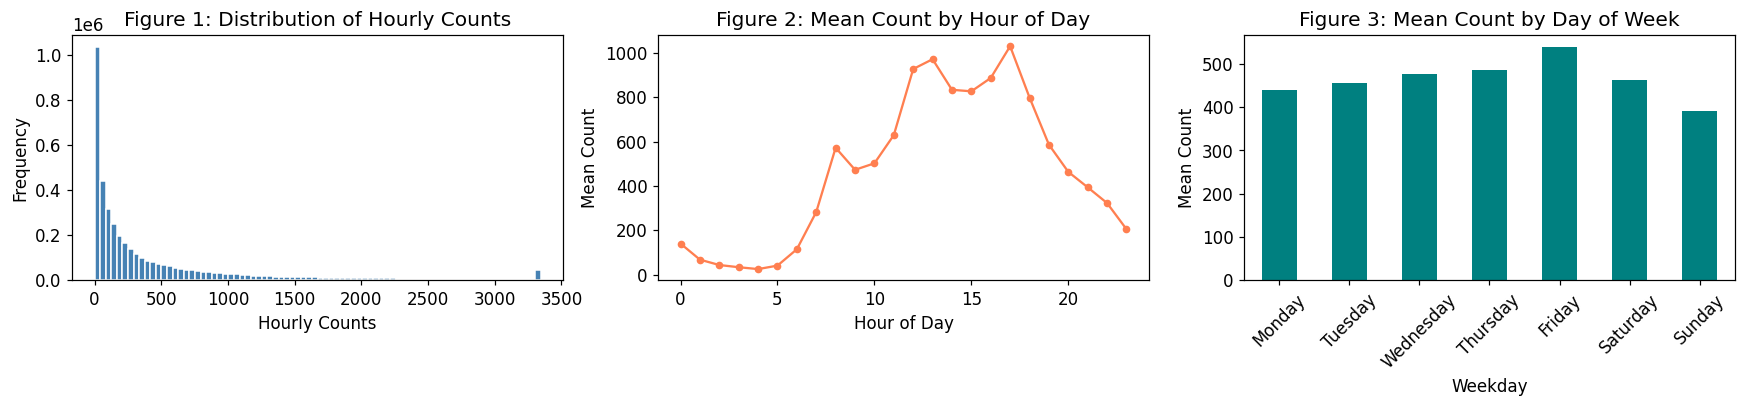

In [5]:
# ── 1.2 Quick EDA ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Count distribution
cap = df['hourly_counts'].quantile(0.99)
axes[0].hist(df['hourly_counts'].clip(upper=cap), bins=80,
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hourly Counts')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Figure 1: Distribution of Hourly Counts')

# Mean by hour-of-day  (column 'time' = 0..23)
df.groupby('time')['hourly_counts'].mean().plot(
    ax=axes[1], color='coral', marker='o', ms=4)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Count')
axes[1].set_title('Figure 2: Mean Count by Hour of Day')

# Mean by weekday
WD_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('weekday')['hourly_counts'].mean().reindex(WD_ORDER).plot(
    kind='bar', ax=axes[2], color='teal')
axes[2].set_xlabel('Weekday')
axes[2].set_ylabel('Mean Count')
axes[2].set_title('Figure 3: Mean Count by Day of Week')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Feature Engineering – Spatial

In [6]:
# ── 2.1 Per-sensor aggregate feature table ────────────────────────────────────
sensor_feats = df.groupby('sensor_id').agg(
    lat           = ('latitude',       'first'),
    lon           = ('longitude',      'first'),
    sensor_name   = ('sensor_name',    'first'),
    location_type = ('location_type',  'first'),
    direction_1   = ('direction_1',    'first'),
    mean_count    = ('hourly_counts',  'mean'),
    std_count     = ('hourly_counts',  'std'),
    max_count     = ('hourly_counts',  'max'),
    total_count   = ('hourly_counts',  'sum'),
    cv            = ('hourly_counts',  lambda x: x.std() / (x.mean() + 1e-9)),
).reset_index()

# ── 2.2 Hour-of-day profile per sensor (h00 .. h23) ──────────────────────────
# 'time' column contains integer hour 0-23
hour_profile = (
    df.groupby(['sensor_id', 'time'])['hourly_counts']
    .mean()
    .unstack(fill_value=0)
)
hour_profile.columns = [f'h{int(c):02d}' for c in hour_profile.columns]
sensor_feats = sensor_feats.merge(hour_profile.reset_index(), on='sensor_id', how='left')

# ── 2.3 Weekend / weekday mean & ratio ───────────────────────────────────────
wk = (
    df.groupby(['sensor_id', 'is_weekend'])['hourly_counts']
    .mean()
    .unstack(fill_value=0)
)
wk.columns = ['weekday_mean', 'weekend_mean']
wk['we_wd_ratio'] = wk['weekend_mean'] / (wk['weekday_mean'] + 1e-9)
sensor_feats = sensor_feats.merge(wk.reset_index(), on='sensor_id', how='left')

# ── 2.4 Distance from Flinders St (CBD centre) ───────────────────────────────
sensor_coords_r = np.radians(sensor_feats[['lat', 'lon']].values)
centre_r        = np.radians([[-37.8183, 144.9671]])
sensor_feats['dist_centre_km'] = haversine_distances(sensor_coords_r, centre_r)[:, 0] * R_EARTH

# ── 2.5 k-NN spatial lag (mean count of 5 nearest neighbours) ────────────────
bt = BallTree(sensor_coords_r, metric='haversine')
dist_knn, idx_knn = bt.query(sensor_coords_r, k=6)   # k+1 (self included)
sensor_feats['nn_mean_count'] = [
    sensor_feats['mean_count'].iloc[idx_knn[i, 1:]].mean()
    for i in range(len(sensor_feats))
]
sensor_feats['nn1_dist_km'] = dist_knn[:, 1] * R_EARTH

print('Spatial feature table:', sensor_feats.shape)
sensor_feats[['sensor_id','sensor_name','lat','lon',
              'mean_count','dist_centre_km','nn_mean_count']].head(5)

Spatial feature table: (73, 41)


,sensor_id,sensor_name,lat,lon,mean_count,dist_centre_km,nn_mean_count
0,1,Bourke Street Mall (North),-37.813494,144.965153,1043.850789,0.561054,735.595718
1,2,Bourke Street Mall (South),-37.813807,144.965167,945.819468,0.527694,755.201983
2,3,Melbourne Central,-37.811015,144.964295,1087.239110,0.846680,462.705149
3,4,Town Hall (West),-37.814880,144.966088,1348.215740,0.390556,686.751920
4,5,Princes Bridge,-37.818742,144.967877,997.015730,0.084106,684.161013


In [7]:
# ── 2.6 GeoDataFrame & Spatial Weights ───────────────────────────────────────
gdf = gpd.GeoDataFrame(
    sensor_feats,
    geometry=gpd.points_from_xy(sensor_feats['lon'], sensor_feats['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:7855')   # MGA2020 Zone 55 – Melbourne projected CRS

W_knn  = KNN.from_dataframe(gdf, k=5);  W_knn.transform  = 'r'
W_dist = DistanceBand.from_dataframe(gdf, threshold=600, binary=True)
W_dist.transform = 'r'

print('KNN  islands:', W_knn.islands)
print('Dist islands:', W_dist.islands)

KNN  islands: []
Dist islands: []


Global Moran's I = 0.3281  (E[I]=-0.0139)  p=0.0010
Geary's c        = 0.6730  (< 1 → positive autocorrelation)  p=0.0010
Interpretation: Clustered – spatial autocorrelation present.


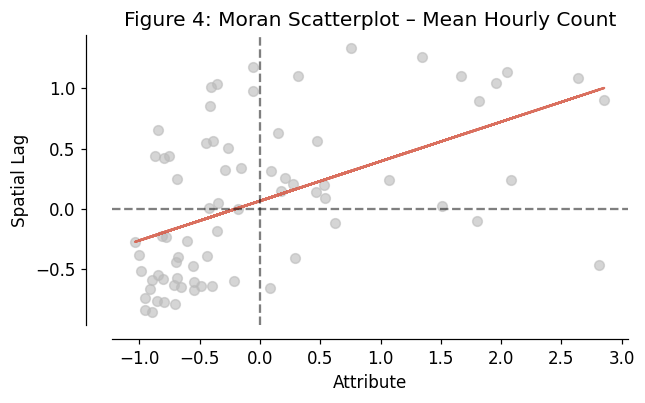

In [8]:
# ── 2.7 Global Moran's I & Geary's c ─────────────────────────────────────────
y_sp = sensor_feats['mean_count'].values

moran = Moran(y_sp, W_knn)
geary = Geary(y_sp, W_knn)

print(f"Global Moran's I = {moran.I:.4f}  (E[I]={moran.EI:.4f})  p={moran.p_sim:.4f}")
print(f"Geary's c        = {geary.C:.4f}  (< 1 → positive autocorrelation)  p={geary.p_sim:.4f}")
print('Interpretation:', 'Clustered – spatial autocorrelation present.'
      if moran.p_sim < 0.05 else 'No significant spatial autocorrelation.')

fig, ax = plt.subplots(figsize=(6, 5))
moran_scatterplot(moran, aspect_equal=True, ax=ax)
ax.set_title("Figure 4: Moran Scatterplot – Mean Hourly Count")
plt.tight_layout()
plt.show()

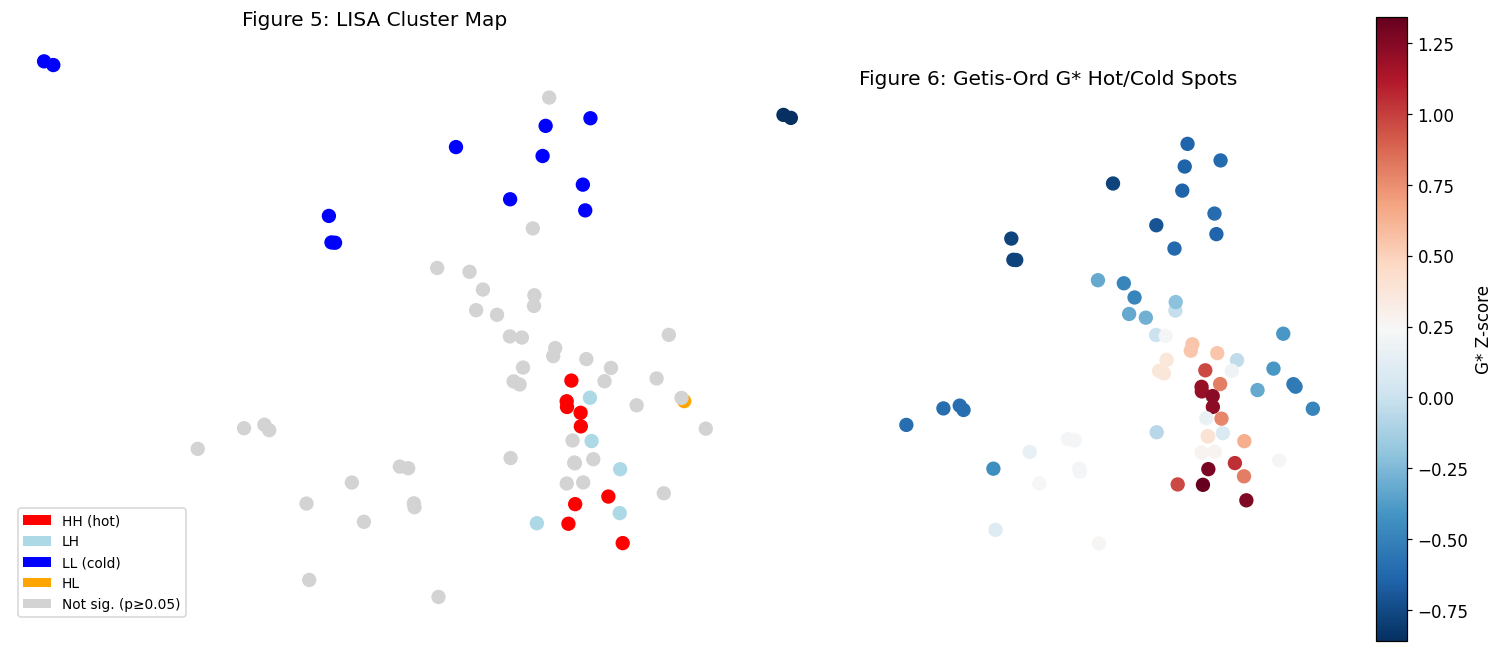

In [9]:
# ── 2.8 Local Moran (LISA) & Getis-Ord G* ────────────────────────────────────
lisa   = Moran_Local(y_sp, W_knn, seed=SEED)
g_star = G_Local(y_sp, W_knn, transform='r', star=True)

sensor_feats['lisa_I']    = lisa.Is
sensor_feats['lisa_q']    = lisa.q       # 1=HH, 2=LH, 3=LL, 4=HL
sensor_feats['lisa_p']    = lisa.p_sim
sensor_feats['g_star_z']  = g_star.Zs
sensor_feats['hot_spot']  = (g_star.Zs >  1.96).astype(int)
sensor_feats['cold_spot'] = (g_star.Zs < -1.96).astype(int)

from matplotlib.patches import Patch
QUAD_COLORS = {1:'red', 2:'lightblue', 3:'blue', 4:'orange'}
QUAD_LABELS = {1:'HH (hot)', 2:'LH', 3:'LL (cold)', 4:'HL'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LISA cluster map
gdf2 = gdf.copy()
gdf2['color'] = sensor_feats['lisa_q'].map(QUAD_COLORS)
gdf2.loc[sensor_feats['lisa_p'].values >= 0.05, 'color'] = 'lightgrey'
gdf2.plot(color=gdf2['color'], markersize=70, ax=axes[0])
legend_els = [Patch(fc=v, label=QUAD_LABELS[k]) for k, v in QUAD_COLORS.items()] + \
             [Patch(fc='lightgrey', label='Not sig. (p≥0.05)')]
axes[0].legend(handles=legend_els, fontsize=9)
axes[0].set_title('Figure 5: LISA Cluster Map')
axes[0].axis('off')

# Getis-Ord G* z-score map
gdf3 = gdf.copy()
gdf3['g_star_z'] = sensor_feats['g_star_z'].values
gdf3.plot(column='g_star_z', cmap='RdBu_r', legend=True,
          markersize=70, ax=axes[1],
          legend_kwds={'label': 'G* Z-score'})
axes[1].set_title('Figure 6: Getis-Ord G* Hot/Cold Spots')
axes[1].axis('off')

plt.tight_layout()
plt.show()

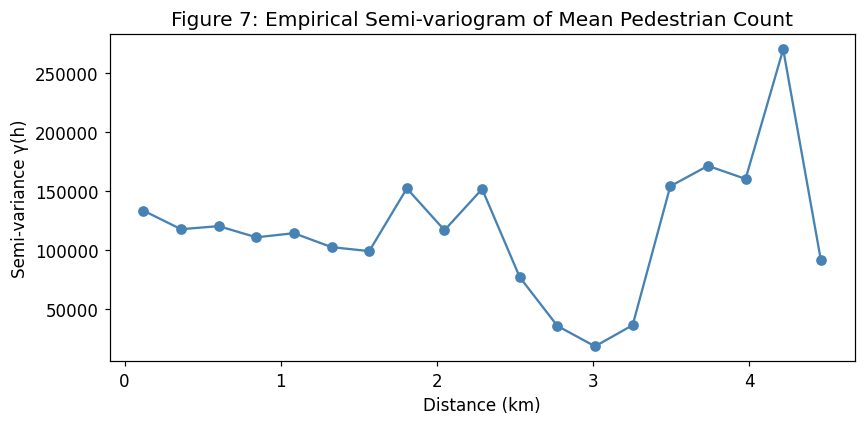

In [10]:
# ── 2.9 Empirical Semi-variogram ──────────────────────────────────────────────
lats = sensor_feats['lat'].values
lons = sensor_feats['lon'].values
vals = sensor_feats['mean_count'].values

h_list, g_list = [], []
for i, j in combinations(range(len(sensor_feats)), 2):
    d = haversine_distances(
        np.radians([[lats[i], lons[i]]]),
        np.radians([[lats[j], lons[j]]])
    )[0, 0] * R_EARTH
    h_list.append(d)
    g_list.append(0.5 * (vals[i] - vals[j]) ** 2)

h_arr, g_arr = np.array(h_list), np.array(g_list)
bins = np.linspace(0, h_arr.max(), 20)
bin_c, bin_g = [], []
for b0, b1 in zip(bins[:-1], bins[1:]):
    mask = (h_arr >= b0) & (h_arr < b1)
    if mask.sum() > 0:
        bin_c.append((b0 + b1) / 2)
        bin_g.append(g_arr[mask].mean())

plt.figure(figsize=(8, 4))
plt.plot(bin_c, bin_g, 'o-', color='steelblue')
plt.xlabel('Distance (km)')
plt.ylabel('Semi-variance γ(h)')
plt.title('Figure 7: Empirical Semi-variogram of Mean Pedestrian Count')
plt.tight_layout()
plt.show()

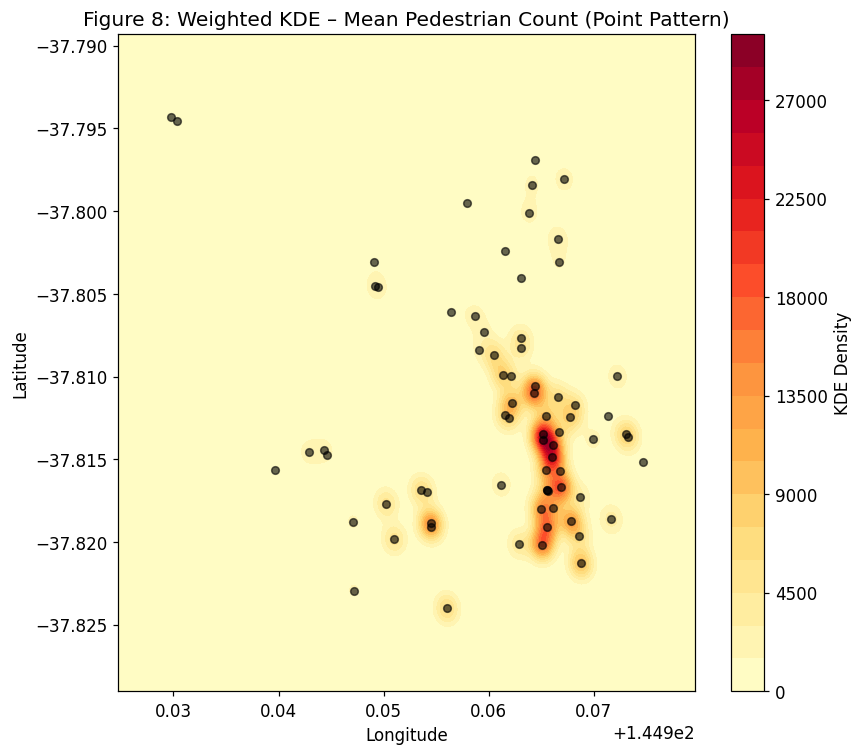

In [11]:
# ── 2.10 Weighted KDE from Point Pattern ──────────────────────────────────────
xi = np.linspace(lons.min() - 0.005, lons.max() + 0.005, 250)
yi = np.linspace(lats.min() - 0.005, lats.max() + 0.005, 250)
Xi, Yi = np.meshgrid(xi, yi)
kde = gaussian_kde(np.vstack([lons, lats]), weights=vals, bw_method=0.12)
Zi  = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)

fig, ax = plt.subplots(figsize=(8, 7))
cont = ax.contourf(Xi, Yi, Zi, levels=25, cmap='YlOrRd')
plt.colorbar(cont, ax=ax, label='KDE Density')
ax.scatter(lons, lats, s=25, c='black', alpha=0.6, zorder=5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Figure 8: Weighted KDE – Mean Pedestrian Count (Point Pattern)')
plt.tight_layout()
plt.show()

In [12]:
# ── 2.11 Mantel Test for Spatial Association ──────────────────────────────────
# Build full square distance matrices (2D numpy arrays)
geo_dist  = haversine_distances(sensor_coords_r) * R_EARTH          # (n, n) km
attr_dist = squareform(pdist(sensor_feats[['mean_count']].values,
                              'euclidean'))                           # (n, n)

def mantel_test(dm1, dm2, n_perm=999, seed=42):
    """Permutation Mantel test on two square distance matrices."""
    rng  = np.random.default_rng(seed)
    n    = dm1.shape[0]
    idx  = np.tril_indices(n, k=-1)   # lower-triangle indices
    x, y = dm1[idx], dm2[idx]
    r_obs, _ = pearsonr(x, y)
    p_arr  = np.arange(n)
    r_perm = []
    for _ in range(n_perm):
        rng.shuffle(p_arr)
        dm2p = dm2[np.ix_(p_arr, p_arr)]
        rp, _ = pearsonr(x, dm2p[idx])
        r_perm.append(rp)
    p_val = (np.sum(np.array(r_perm) >= r_obs) + 1) / (n_perm + 1)
    return r_obs, p_val

r_m, p_m = mantel_test(geo_dist, attr_dist)
print(f'Mantel Test: r={r_m:.4f},  p={p_m:.4f}')
print('Result:', 'Spatial autocorrelation confirmed (p<0.05).' if p_m < 0.05
      else 'No significant spatial association.')

Mantel Test: r=-0.0202,  p=0.5520
Result: No significant spatial association.


## 3. Feature Engineering – Temporal

In [13]:
# ── 3.1 Build city-wide & top-sensor hourly series ────────────────────────────
ts_city = (
    df.groupby('date_time')['hourly_counts']
    .sum()
    .sort_index()
    .asfreq('H')
    .fillna(method='ffill')
)

top_sid  = sensor_feats.sort_values('mean_count', ascending=False).iloc[0]['sensor_id']
top_name = sensor_feats[sensor_feats['sensor_id'] == top_sid]['sensor_name'].values[0]
print(f'City-wide series length: {len(ts_city)}')
print(f'Top sensor: ID={top_sid}, Name={top_name}')

ts_top = (
    df[df['sensor_id'] == top_sid]
    .groupby('date_time')['hourly_counts']
    .mean()  # Aggregates any duplicate timestamps into a single average
    .sort_index()
    .asfreq('H')
    .ffill() # Tip: .ffill() is the modern pandas equivalent to .fillna(method='ffill')
)

City-wide series length: 118368
Top sensor: ID=4, Name=Town Hall (West)


In [14]:
# ── 3.2 Temporal feature engineering ─────────────────────────────────────────
def make_temporal_features(series: pd.Series) -> pd.DataFrame:
    """Rich temporal feature table from an hourly DatetimeIndex series."""
    idx  = series.index
    feat = pd.DataFrame({'count': series.values}, index=idx)

    # Calendar
    feat['hour']       = idx.hour
    feat['dow']        = idx.dayofweek
    feat['month']      = idx.month
    feat['quarter']    = idx.quarter
    feat['year']       = idx.year
    feat['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    feat['is_night']   = ((idx.hour < 6) | (idx.hour >= 22)).astype(int)
    feat['is_peak']    = (
        ((idx.hour >= 7) & (idx.hour <= 9)) |
        ((idx.hour >= 16) & (idx.hour <= 19))
    ).astype(int)

    # Fourier features (hourly + annual seasonality)
    for k in [1, 2, 3]:
        feat[f'sin_h{k}'] = np.sin(2 * np.pi * k * idx.hour / 24)
        feat[f'cos_h{k}'] = np.cos(2 * np.pi * k * idx.hour / 24)
        feat[f'sin_d{k}'] = np.sin(2 * np.pi * k * idx.dayofyear / 365.25)
        feat[f'cos_d{k}'] = np.cos(2 * np.pi * k * idx.dayofyear / 365.25)

    # Lag features (hours back)
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        feat[f'lag_{lag}h'] = feat['count'].shift(lag)

    # Rolling statistics (shift 1 to avoid leakage)
    for w in [6, 24, 168]:
        feat[f'roll_mean_{w}h'] = feat['count'].shift(1).rolling(w).mean()
        feat[f'roll_std_{w}h']  = feat['count'].shift(1).rolling(w).std()

    # Difference features
    feat['diff1']   = feat['count'].diff(1)
    feat['diff24']  = feat['count'].diff(24)
    feat['diff168'] = feat['count'].diff(168)

    return feat.dropna()

feat_ts_city = make_temporal_features(ts_city)
feat_ts_top  = make_temporal_features(ts_top)
print('City temporal features:', feat_ts_city.shape)
print('Top-sensor features:   ', feat_ts_top.shape)

City temporal features: (118200, 38)
Top-sensor features:    (118200, 38)


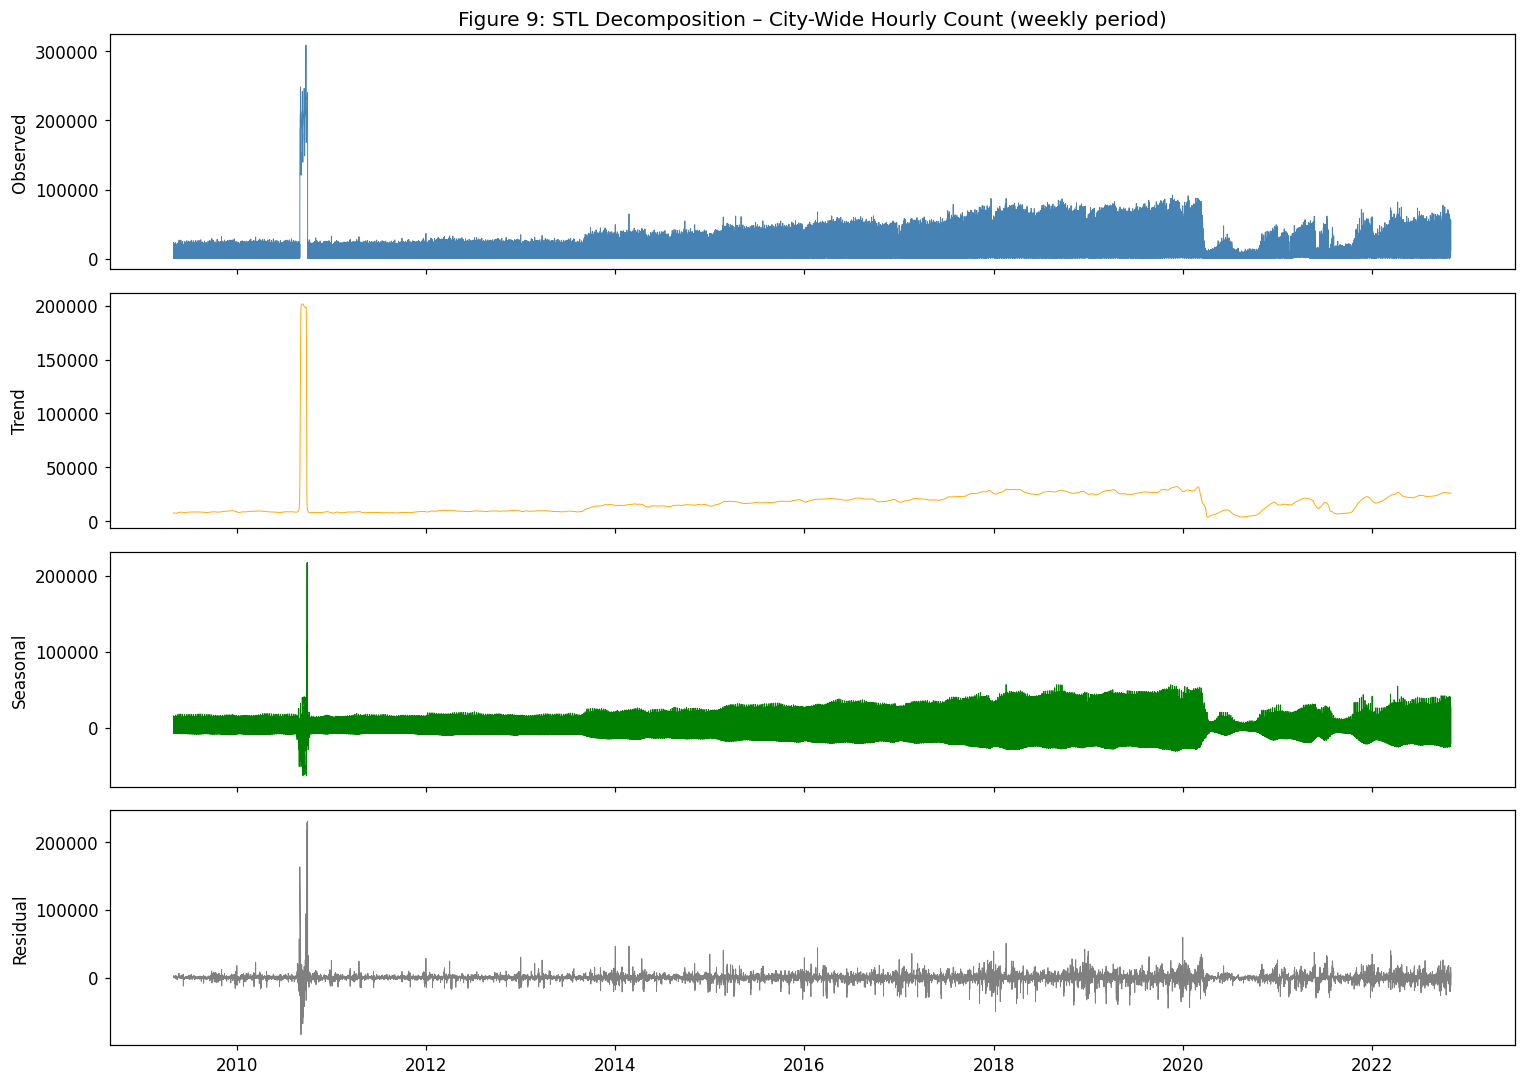

In [15]:
# ── 3.3 STL Decomposition (weekly period = 168 hours) ─────────────────────────
stl = STL(ts_city, period=24*7, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
comps = [(res.observed,'Observed','steelblue'),
         (res.trend,   'Trend',   'orange'),
         (res.seasonal,'Seasonal','green'),
         (res.resid,   'Residual','grey')]
for ax, (comp, label, col) in zip(axes, comps):
    ax.plot(comp, lw=0.6, color=col)
    ax.set_ylabel(label)
axes[0].set_title('Figure 9: STL Decomposition – City-Wide Hourly Count (weekly period)')
plt.tight_layout()
plt.show()

# Add STL components as features for temporal ML
stl_df = pd.DataFrame({
    'stl_trend'   : res.trend,
    'stl_seasonal': res.seasonal,
    'stl_resid'   : res.resid
}, index=ts_city.index)
feat_ts_city = feat_ts_city.join(stl_df, how='left').fillna(0)

In [16]:
# ── 3.4 Stationarity Tests (ADF + KPSS) ──────────────────────────────────────
# Sub-sample for speed: use last 8760 hours (1 year) — sufficient for stationarity tests
STAT_SAMPLE = 8760

def adf_kpss(series, name):
    s = series.dropna().iloc[-STAT_SAMPLE:]   # cap at 1 year of hourly data
    adf_s, adf_p = adfuller(s, maxlag=48)[:2]           # limit lags to 48 h
    kpss_s, kpss_p = kpss(s, regression='c', nlags=10)[:2]  # fixed small nlags
    print(f'[{name}]  (sample size={len(s)})')
    print(f'  ADF  stat={adf_s:8.4f}  p={adf_p:.4f}  '
          f'→ {"Stationary" if adf_p < 0.05 else "Non-stationary"}')
    print(f'  KPSS stat={kpss_s:8.4f}  p={kpss_p:.4f}  '
          f'→ {"Stationary" if kpss_p > 0.05 else "Non-stationary"}')

adf_kpss(ts_city,                    'Raw hourly city series')
adf_kpss(ts_city.diff(24).dropna(),  'After 24-h differencing')
adf_kpss(ts_city.diff(168).dropna(), 'After weekly differencing')

[Raw hourly city series]  (sample size=8760)
  ADF  stat= -8.9639  p=0.0000  → Stationary
  KPSS stat=  1.9522  p=0.0100  → Non-stationary
[After 24-h differencing]  (sample size=8760)
  ADF  stat=-16.0705  p=0.0000  → Stationary
  KPSS stat=  0.0046  p=0.1000  → Stationary
[After weekly differencing]  (sample size=8760)
  ADF  stat= -9.3099  p=0.0000  → Stationary
  KPSS stat=  0.3331  p=0.1000  → Stationary


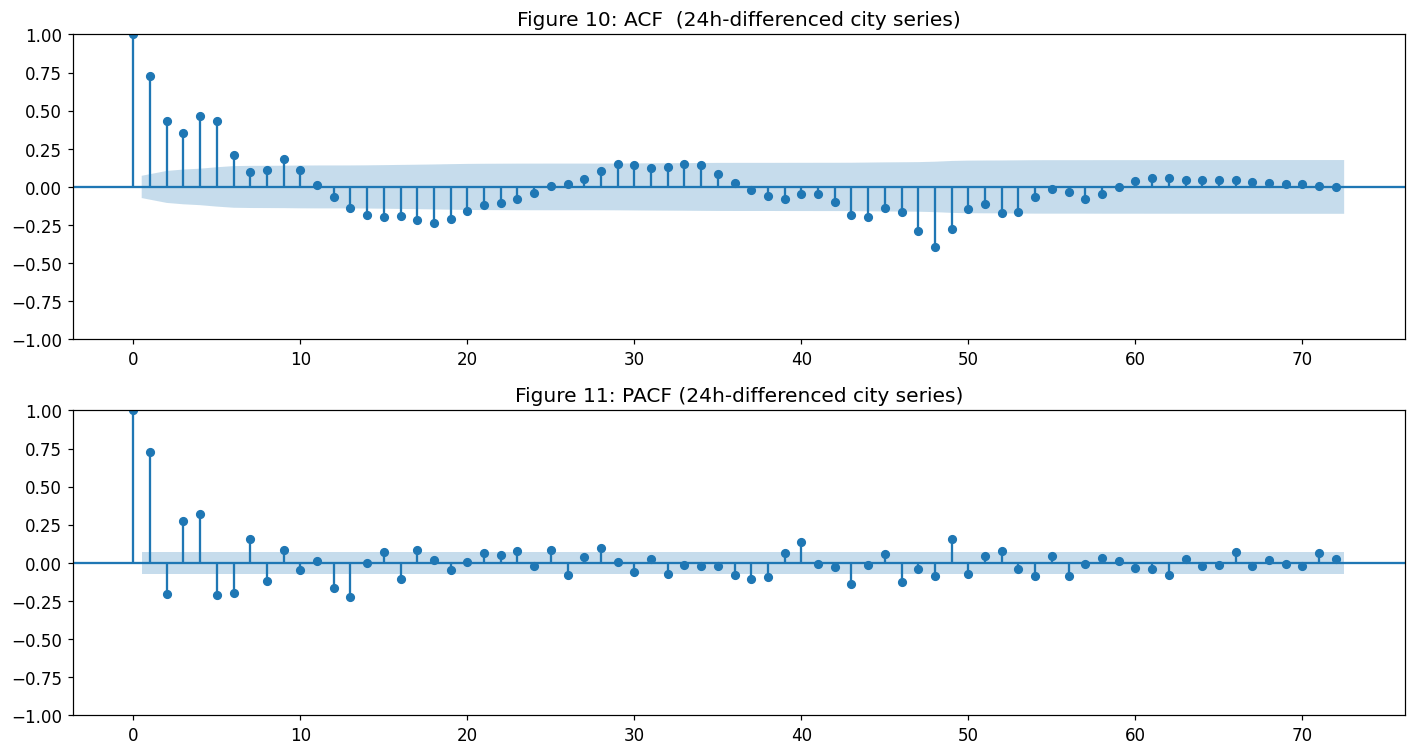

In [17]:
# ── 3.5 ACF / PACF ───────────────────────────────────────────────────────────
sample = ts_city.diff(24).dropna().iloc[:24*30]   # 30 days for clarity

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
plot_acf( sample, lags=72, ax=axes[0],
          title='Figure 10: ACF  (24h-differenced city series)')
plot_pacf(sample, lags=72, ax=axes[1],
          title='Figure 11: PACF (24h-differenced city series)')
plt.tight_layout()
plt.show()

## 4. ML Models – Spatial Aspect

In [27]:
# ── 4.1 Prepare spatial ML dataset ───────────────────────────────────────────
SPATIAL_FEATS = [
    'lat', 'lon', 'dist_centre_km', 'nn1_dist_km',
    'cv', 'we_wd_ratio', 'nn_mean_count',
    'lisa_I', 'g_star_z'
]
SPATIAL_FEATS = [c for c in SPATIAL_FEATS if c in sensor_feats.columns]

X_sp     = sensor_feats[SPATIAL_FEATS].values
y_sp_log = np.log1p(sensor_feats['mean_count'].values)   # log-transform target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sp, y_sp_log, test_size=0.2, random_state=SEED)

scaler_sp = StandardScaler()
X_tr_s = scaler_sp.fit_transform(X_tr)
X_te_s = scaler_sp.transform(X_te)

def eval_reg(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    p    = model.predict(Xte)
    mae  = mean_absolute_error(yte, p)
    rmse = np.sqrt(mean_squared_error(yte, p))
    r2   = r2_score(yte, p)
    print(f'{name:40s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return p, r2

print('=== Spatial ML (target: log1p mean_count per sensor) ===')
SP_MODELS = [
    ('Ridge Regression',     Ridge(alpha=1.0)),
    ('Lasso Regression',     Lasso(alpha=0.01)),
    ('KNN Regressor (k=5)',  KNeighborsRegressor(n_neighbors=5)),
    ('Random Forest',        RandomForestRegressor(n_estimators=200, random_state=SEED)),
    ('Gradient Boosting',    GradientBoostingRegressor(n_estimators=200, random_state=SEED)),
    ('MLP Neural Network',   MLPRegressor(hidden_layer_sizes=(64,32),
                                          max_iter=500, random_state=SEED)),
]
sp_r2 = {}
for name, model in SP_MODELS:
    _, r2 = eval_reg(name, model, X_tr_s, y_tr, X_te_s, y_te)
    sp_r2[name] = r2

=== Spatial ML (target: log1p mean_count per sensor) ===
Ridge Regression                          MAE=0.2075  RMSE=0.3174  R²=0.8747
Lasso Regression                          MAE=0.1766  RMSE=0.2584  R²=0.9170
KNN Regressor (k=5)                       MAE=0.4020  RMSE=0.5522  R²=0.6209
Random Forest                             MAE=0.2904  RMSE=0.3948  R²=0.8063
Gradient Boosting                         MAE=0.2925  RMSE=0.3987  R²=0.8024
MLP Neural Network                        MAE=0.6199  RMSE=0.7892  R²=0.2258


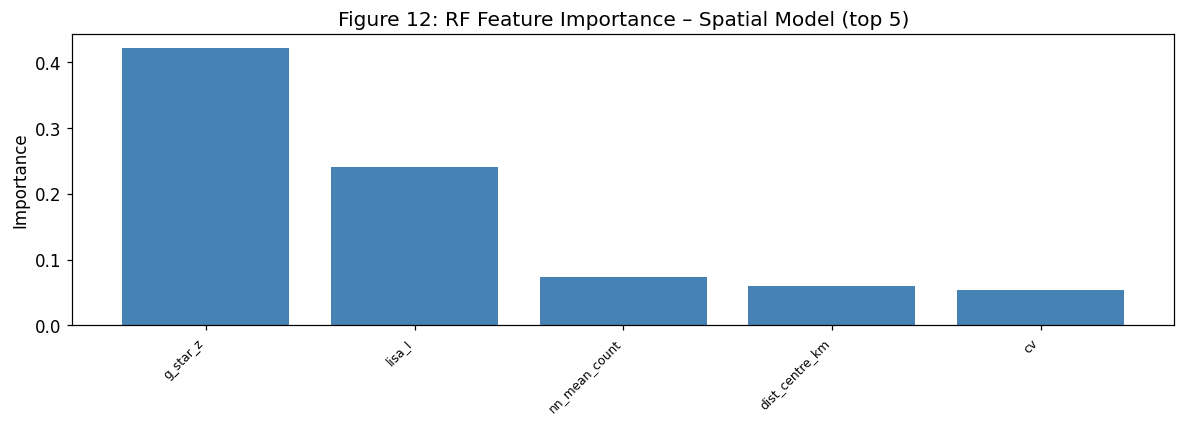

In [28]:
# ── 4.2 RF Feature Importance ────────────────────────────────────────────────
rf_sp = RandomForestRegressor(n_estimators=300, random_state=SEED)
rf_sp.fit(X_tr_s, y_tr)
imp    = rf_sp.feature_importances_
top5  = np.argsort(imp)[::-1][:5]

plt.figure(figsize=(11, 4))
plt.bar(range(5), imp[top5], color='steelblue')
plt.xticks(range(5), [SPATIAL_FEATS[i] for i in top5],
           rotation=45, ha='right', fontsize=8)
plt.ylabel('Importance')
plt.title('Figure 12: RF Feature Importance – Spatial Model (top 5)')
plt.tight_layout()
plt.show()

In [29]:
# ── 4.3 Spatial Autoregression (Lag & Error) ──────────────────────────────────
try:
    from spreg import OLS, ML_Lag, ML_Error

    y_sar  = np.log1p(sensor_feats['mean_count'].values).reshape(-1, 1)
    x_cols = ['dist_centre_km', 'cv', 'we_wd_ratio']
    x_cols = [c for c in x_cols if c in sensor_feats.columns]
    X_sar  = sensor_feats[x_cols].values

    print('--- OLS Baseline ---')
    print(OLS(y_sar, X_sar, name_y='log_count', name_x=x_cols).summary)

    print('\n--- Spatial Lag Model ---')
    print(ML_Lag(y_sar, X_sar, w=W_knn, name_y='log_count', name_x=x_cols).summary)

    print('\n--- Spatial Error Model ---')
    print(ML_Error(y_sar, X_sar, w=W_knn, name_y='log_count', name_x=x_cols).summary)

except ImportError:
    print('[INFO] spreg not installed. Run: pip install spreg')

--- OLS Baseline ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   log_count                Number of Observations:          73
Mean dependent var  :      5.5578                Number of Variables   :           4
S.D. dependent var  :      0.9174                Degrees of Freedom    :          69
R-squared           :      0.3584
Adjusted R-squared  :      0.3305
Sum squared residual:     38.8762                F-statistic           :     12.8494
Sigma-square        :       0.563                Prob(F-statistic)     :     9.2e-07
S.E. of regression  :       0.751                Log likelihood        :     -80.585
Sigma-square ML     :       0.533                Akaike info criterion :     169.169
S.E of regression ML:      0.7298                Schwarz criterion     :     178.331

---------------------------------------

GWR bandwidth: 50.0
Model type                                                         Gaussian
Number of observations:                                                  73
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                             38.876
Log-likelihood:                                                     -80.585
AIC:                                                                169.169
AICc:                                                               172.065
BIC:                                                               -257.166
R2:                                                                   0.358
Adj. R2:                                                              0.331

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- --------

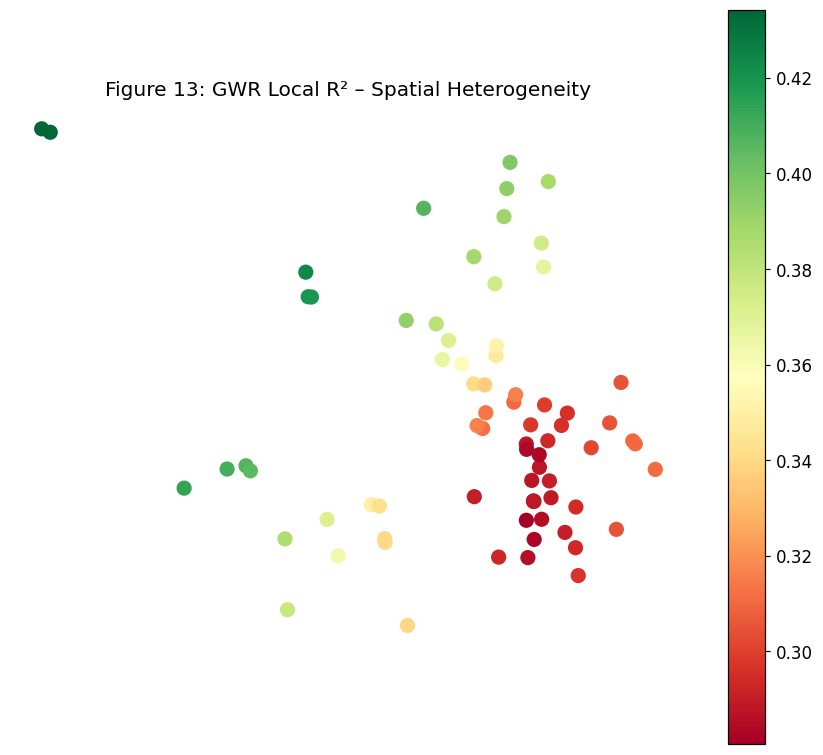

In [30]:
# ── 4.4 Geographically Weighted Regression (GWR) ─────────────────────────────
try:
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW

    gdf_proj   = gdf.to_crs('EPSG:7855')
    coords_gwr = np.column_stack([gdf_proj.geometry.x, gdf_proj.geometry.y])
    gwr_xcols  = ['dist_centre_km', 'cv', 'we_wd_ratio']
    gwr_xcols  = [c for c in gwr_xcols if c in sensor_feats.columns]
    X_gwr = StandardScaler().fit_transform(sensor_feats[gwr_xcols].values)
    y_gwr = np.log1p(sensor_feats['mean_count'].values).reshape(-1, 1)

    bw      = Sel_BW(coords_gwr, y_gwr, X_gwr, kernel='gaussian', fixed=False).search()
    gwr_res = GWR(coords_gwr, y_gwr, X_gwr, bw=bw, kernel='gaussian', fixed=False).fit()
    print(f'GWR bandwidth: {bw}')
    print(gwr_res.summary())

    sensor_feats['gwr_local_r2'] = gwr_res.localR2
    gdf_gwr = gdf.copy()
    gdf_gwr['local_r2'] = gwr_res.localR2
    ax = gdf_gwr.plot(column='local_r2', cmap='RdYlGn', legend=True,
                      markersize=80, figsize=(8, 7))
    ax.set_title('Figure 13: GWR Local R² – Spatial Heterogeneity')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

except ImportError:
    print('[INFO] mgwr not installed. Run: pip install mgwr')

## 5. ML Models – Temporal Aspect

In [31]:
# ── 5.1 Daily series & helpers ────────────────────────────────────────────────
ts_daily = ts_top.resample('D').sum()
N_TEST_D = 60
ts_d_tr  = ts_daily.iloc[:-N_TEST_D]
ts_d_te  = ts_daily.iloc[-N_TEST_D:]

def ts_metrics(name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / (np.abs(actual) + 1e-9))) * 100
    print(f'{name:48s}  MAE={mae:8.1f}  RMSE={rmse:8.1f}  MAPE={mape:.2f}%')
    return mae, rmse

Best ARIMA order (MDL/BIC): (3, 1, 3)  BIC=21684.65


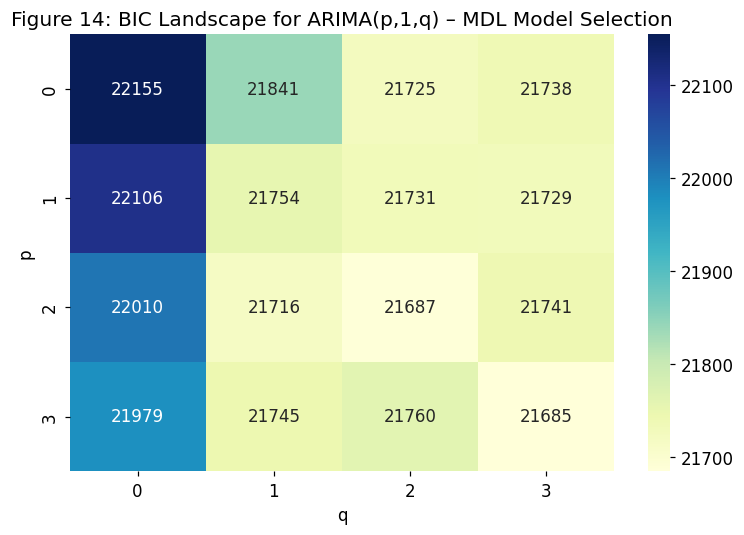

In [32]:
# ── 5.2 MDL / BIC – ARIMA Order Selection ────────────────────────────────────
ts_sel = ts_daily.iloc[:365*3]
bic_scores = {}
for p in range(0, 4):
    for q in range(0, 4):
        try:
            m = ARIMA(ts_sel, order=(p, 1, q)).fit()
            bic_scores[(p, 1, q)] = m.bic
        except Exception:
            pass

best_order = min(bic_scores, key=bic_scores.get)
print(f'Best ARIMA order (MDL/BIC): {best_order}  BIC={bic_scores[best_order]:.2f}')

bic_df = pd.DataFrame(
    [(o[0], o[2], v) for o, v in bic_scores.items()],
    columns=['p', 'q', 'bic']
).pivot(index='p', columns='q', values='bic')

plt.figure(figsize=(7, 5))
sns.heatmap(bic_df, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Figure 14: BIC Landscape for ARIMA(p,1,q) – MDL Model Selection')
plt.tight_layout()
plt.show()

In [33]:
# ── 5.3 SARIMA ────────────────────────────────────────────────────────────────
p_best, d_best, q_best = best_order
print(f'Using BIC-selected order: SARIMA({p_best},1,{q_best})(1,1,1,7)')
sarima_fit = SARIMAX(
    ts_d_tr, order=(p_best, 1, q_best), seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
print(sarima_fit.summary())

sarima_pred = sarima_fit.forecast(steps=N_TEST_D)
ts_metrics(f'SARIMA({p_best},1,{q_best})(1,1,1,7) daily', ts_d_te.values, sarima_pred.values)

Using BIC-selected order: SARIMA(3,1,3)(1,1,1,7)
                                      SARIMAX Results                                      
Dep. Variable:                       hourly_counts   No. Observations:                 4872
Model:             SARIMAX(3, 1, 3)x(1, 1, [1], 7)   Log Likelihood              -46682.633
Date:                             Thu, 30 Apr 2026   AIC                          93383.265
Time:                                     21:06:37   BIC                          93441.652
Sample:                                 05-01-2009   HQIC                         93403.760
                                      - 09-01-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8701      0.055    -15.828      0.000   

(7221.013679185223, np.float64(10336.076042426588))

Holt-Winters (mul seasonal, add trend)            MAE=  6728.2  RMSE=  9569.1  MAPE=21.57%
Simple Exponential Smoothing                      MAE=  6616.5  RMSE= 10129.5  MAPE=20.14%


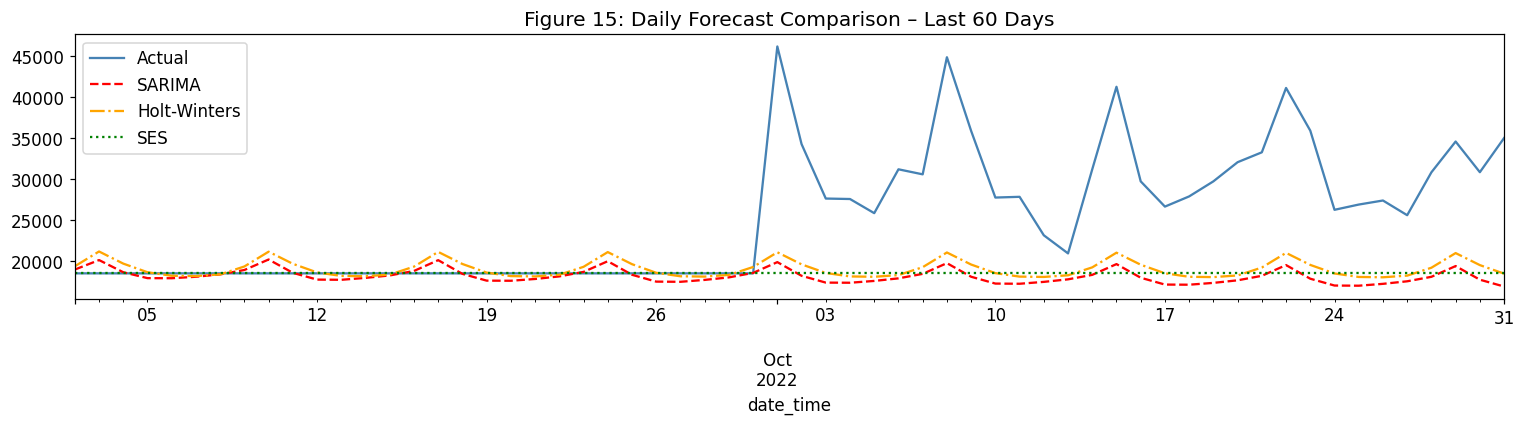

In [34]:
# ── 5.4 Holt-Winters & SES ────────────────────────────────────────────────────
hw_pred  = ExponentialSmoothing(
    ts_d_tr, seasonal='mul', trend='add', seasonal_periods=7
).fit(optimized=True).forecast(N_TEST_D)

ses_pred = SimpleExpSmoothing(ts_d_tr).fit(optimized=True).forecast(N_TEST_D)

ts_metrics('Holt-Winters (mul seasonal, add trend)', ts_d_te.values, hw_pred.values)
ts_metrics('Simple Exponential Smoothing',           ts_d_te.values, ses_pred.values)

plt.figure(figsize=(14, 4))
ts_d_te.plot(  label='Actual',       color='steelblue', lw=1.5)
sarima_pred.plot(label='SARIMA',     color='red',       linestyle='--')
hw_pred.plot(  label='Holt-Winters', color='orange',    linestyle='-.')
ses_pred.plot( label='SES',          color='green',     linestyle=':')
plt.title('Figure 15: Daily Forecast Comparison – Last 60 Days')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# ── 5.5 Feature-based Temporal ML (hourly, top sensor) ───────────────────────
# Exclude target and diff features — diff1/24/168 contain count[t] implicitly
# (diff1 = count[t] - lag_1h, so Linear Regression can recover count[t] exactly)
INPUT_COLS = [c for c in feat_ts_top.columns
              if c not in ('count', 'diff1', 'diff24', 'diff168')]
split_idx  = int(len(feat_ts_top) * 0.8)

X_ts_tr_s = StandardScaler().fit_transform(feat_ts_top.iloc[:split_idx][INPUT_COLS].values)
y_ts_tr   = feat_ts_top.iloc[:split_idx]['count'].values

scaler_ts = StandardScaler().fit(feat_ts_top.iloc[:split_idx][INPUT_COLS].values)
X_ts_tr_s = scaler_ts.transform(feat_ts_top.iloc[:split_idx][INPUT_COLS].values)
X_ts_te_s = scaler_ts.transform(feat_ts_top.iloc[split_idx:][INPUT_COLS].values)
y_ts_te   = feat_ts_top.iloc[split_idx:]['count'].values

print('=== Temporal ML Models (hourly count, top sensor) ===')
TS_MODELS = [
    ('Linear Regression',   LinearRegression()),
    ('Ridge Regression',    Ridge(alpha=10)),
    ('Random Forest',       RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED)),
    ('Gradient Boosting',   GradientBoostingRegressor(n_estimators=200, random_state=SEED)),
    ('MLP Neural Network',  MLPRegressor(hidden_layer_sizes=(128,64),
                                         max_iter=500, random_state=SEED)),
]
if BOOST_OK:
    TS_MODELS += [
        ('XGBoost',  XGBRegressor(n_estimators=200, random_state=SEED, verbosity=0)),
    ]

best_mae, best_preds, best_name = np.inf, None, ''
for name, model in TS_MODELS:
    model.fit(X_ts_tr_s, y_ts_tr)
    p = np.clip(model.predict(X_ts_te_s), 0, None)
    mae, _ = ts_metrics(name, y_ts_te, p)
    if mae < best_mae:
        best_mae, best_preds, best_name = mae, p, name

print(f'\nBest: {best_name}  MAE={best_mae:.1f}')

=== Temporal ML Models (hourly count, top sensor) ===
Linear Regression                                 MAE=   111.8  RMSE=   160.2  MAPE=11933631982.31%
Ridge Regression                                  MAE=   111.7  RMSE=   160.1  MAPE=11932726103.93%
Random Forest                                     MAE=   152.0  RMSE=   207.6  MAPE=9779420563.49%
Gradient Boosting                                 MAE=   194.1  RMSE=   305.5  MAPE=18675859264.65%
MLP Neural Network                                MAE=   185.1  RMSE=   251.1  MAPE=18127277965.04%
XGBoost                                           MAE=   194.2  RMSE=   292.0  MAPE=11671664356.91%

Best: Ridge Regression  MAE=111.7


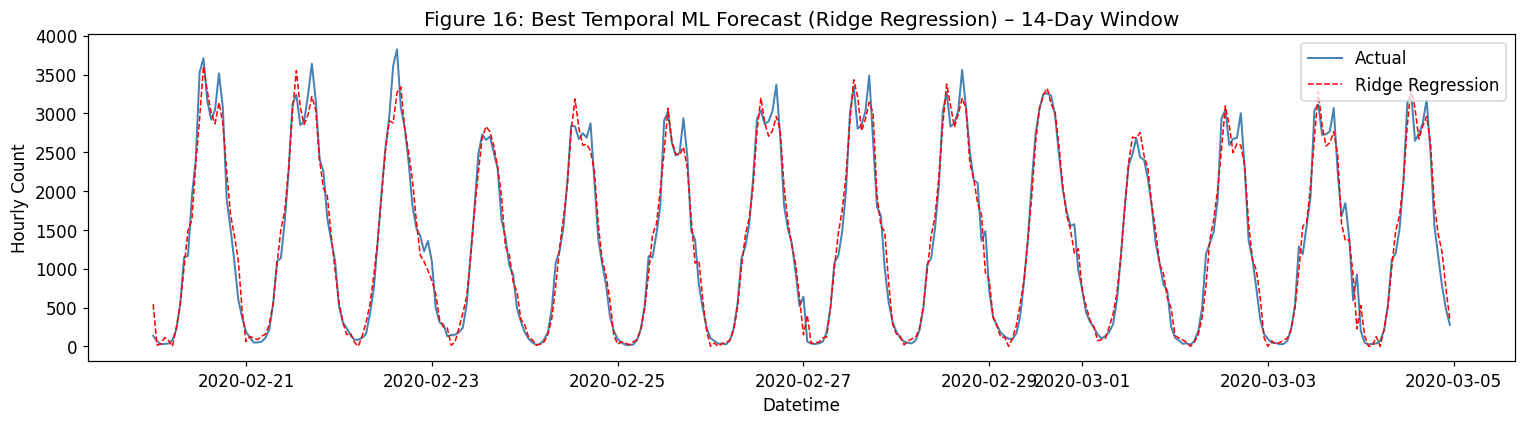

In [36]:
# ── 5.6 Best model 14-day forecast plot ──────────────────────────────────────
test_times = feat_ts_top.iloc[split_idx:].index
W = 24 * 14
plt.figure(figsize=(14, 4))
plt.plot(test_times[:W], y_ts_te[:W],    label='Actual',       color='steelblue', lw=1.3)
plt.plot(test_times[:W], best_preds[:W], label=best_name,      color='red',       lw=1, linestyle='--')
plt.xlabel('Datetime')
plt.ylabel('Hourly Count')
plt.title(f'Figure 16: Best Temporal ML Forecast ({best_name}) – 14-Day Window')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Spatial Data Mining

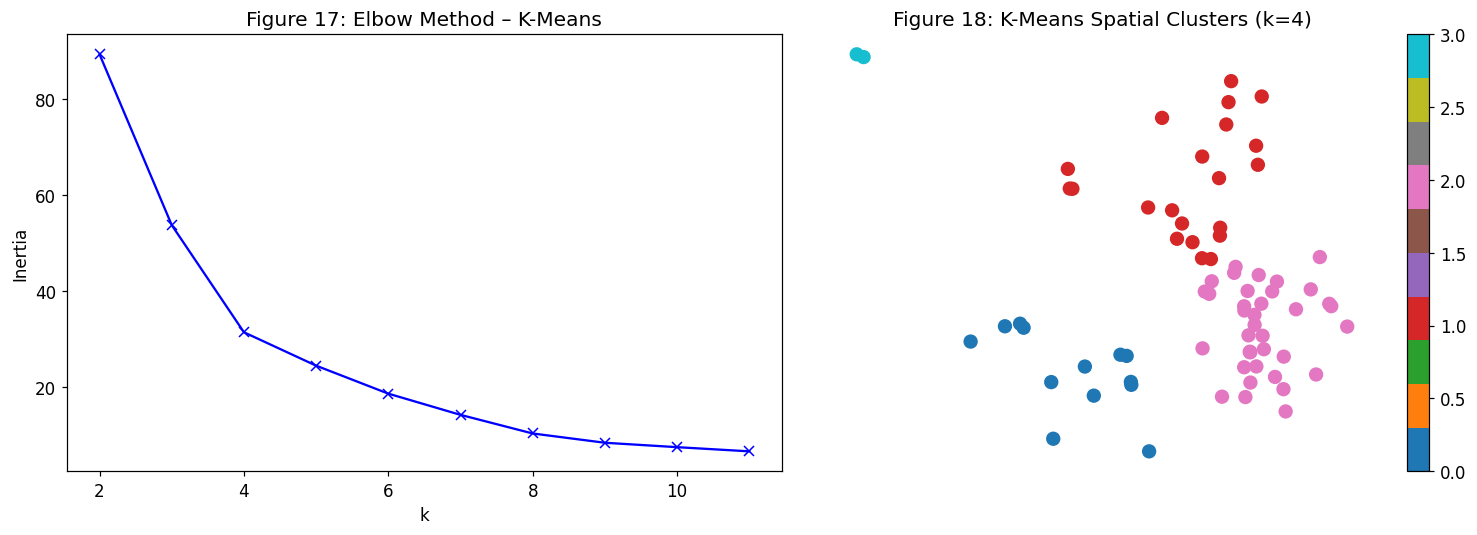

In [37]:
# ── 6.1 K-Means Spatial Clustering ───────────────────────────────────────────
X_cl = StandardScaler().fit_transform(sensor_feats[['lat','lon']].values)

inertia = [
    KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_cl).inertia_
    for k in range(2, 12)
]

km4 = KMeans(n_clusters=4, random_state=SEED, n_init=10)
sensor_feats['km_label'] = km4.fit_predict(X_cl)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 12), inertia, 'bx-')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Figure 17: Elbow Method – K-Means')

gdf_cl = gdf.copy()
gdf_cl['km_label'] = sensor_feats['km_label'].values
gdf_cl.plot(column='km_label', cmap='tab10', markersize=70, legend=True, ax=axes[1])
axes[1].set_title('Figure 18: K-Means Spatial Clusters (k=4)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

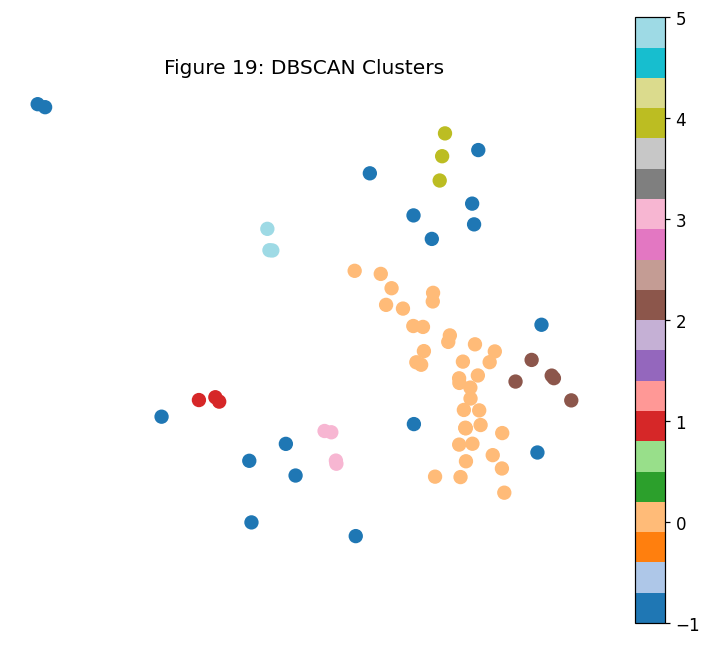

In [38]:
# ── 6.2 DBSCAN ───────────────────────────────────────────────────────────────
sensor_feats['dbscan_label'] = DBSCAN(eps=0.3, min_samples=3).fit_predict(X_cl)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

gdf_db = gdf.copy()
gdf_db['db'] = sensor_feats['dbscan_label'].values
gdf_db.plot(column='db', cmap='tab20', markersize=70, legend=True, ax=ax)
ax.set_title('Figure 19: DBSCAN Clusters'); ax.axis('off')

plt.tight_layout()
plt.show()


In [39]:
# ── 6.3 Collocation Mining ────────────────────────────────────────────────────
# Weekly aggregation (not daily) keeps the matrix small on Kaggle RAM
import gc
ts_wide = (
    df.groupby(['sensor_id', pd.Grouper(key='date_time', freq='W')])['hourly_counts']
    .sum()
    .unstack(level=0)
    .fillna(0)
)
ts_wide.columns = [sensor_map[c] if c in sensor_map.index else str(c) for c in ts_wide.columns]
print(f'ts_wide shape: {ts_wide.shape}')  # rows=weeks, cols=sensors
corr_mat     = ts_wide.corr()
sensors_list = corr_mat.columns.tolist()

collocated = [
    (sensors_list[i], sensors_list[j], round(corr_mat.iloc[i, j], 4))
    for i, j in combinations(range(len(sensors_list)), 2)
    if corr_mat.iloc[i, j] > 0.85
]
df_coll = pd.DataFrame(collocated, columns=['sensor_a', 'sensor_b', 'pearson_r'])
print(f'Collocated sensor pairs (r > 0.85): {len(df_coll)}')
gc.collect()
df_coll.sort_values('pearson_r', ascending=False).head(10)

ts_wide shape: (706, 73)
Collocated sensor pairs (r > 0.85): 133


,sensor_a,sensor_b,pearson_r
93,Flinders Ln -Degraves St (South),Flinders Ln -Degraves St (North),0.9964
130,Elizabeth St - Flinders St (East) - New footpath,Macaulay Rd (North),0.9901
131,Elizabeth St - Flinders St (East) - New footpath,Queensberry St - Errol St (South),0.9894
132,Macaulay Rd (North),Queensberry St - Errol St (South),0.9818
94,Flinders Ln -Degraves St (South),Flinders Ln -Degraves St (Crossing),0.9791
100,Flinders Ln -Degraves St (North),Flinders Ln -Degraves St (Crossing),0.9764
54,Monash Rd-Swanston St (West),Tin Alley-Swanston St (West),0.9730
86,State Library-New,Flinders Ln -Degraves St (North),0.9614
85,State Library-New,Flinders Ln -Degraves St (South),0.9613
118,Flinders St-ACMI,Spring St- Flinders St (West),0.9606


In [40]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
import gc

TOP_N = 30
top_sensors = sensor_feats.nlargest(TOP_N, 'mean_count')['sensor_id'].tolist()
df_top = df[df['sensor_id'].isin(top_sensors)].copy()
df_top['year_month'] = df_top['date_time'].dt.to_period('M')

pivot_m = (
    df_top.groupby(['sensor_id', 'year_month'])['hourly_counts']
    .sum()
    .unstack(level=0)
    .fillna(0)
)
pivot_bin = pivot_m.apply(lambda col: col >= col.median()).astype(bool)
pivot_bin.columns = [f'S{c}' for c in pivot_bin.columns]

# Free up memory before running the heavy data mining algorithm
del df_top
gc.collect()

# Use fpgrowth instead of apriori, increase min_support, and set a max_len
freq_items = fpgrowth(pivot_bin, min_support=0.25, use_colnames=True, max_len=4)

# Generate rules with a slightly stricter lift threshold to filter noise
rules = association_rules(freq_items, metric='lift', min_threshold=1.2)

print(f'Association rules found: {len(rules)}')

# Display the top 10 strongest rules
rules.sort_values('lift', ascending=False)[
    ['antecedents','consequents','support','confidence','lift']
].head(10)

Association rules found: 183530


,antecedents,consequents,support,confidence,lift
130810,"(S19, S6)","(S9, S53)",0.308642,0.862069,2.738337
130815,"(S9, S53)","(S19, S6)",0.308642,0.980392,2.738337
69663,"(S6, S1)","(S9, S53)",0.302469,0.859649,2.730650
69662,"(S9, S53)","(S6, S1)",0.302469,0.960784,2.730650
69841,"(S1, S53)","(S19, S6)",0.302469,0.960784,2.683570
69836,"(S19, S6)","(S1, S53)",0.302469,0.844828,2.683570
131525,"(S14, S53)","(S19, S6)",0.271605,0.956522,2.671664
131520,"(S19, S6)","(S14, S53)",0.271605,0.758621,2.671664
131075,"(S9, S53)","(S25, S6)",0.283951,0.901961,2.656684
131070,"(S25, S6)","(S9, S53)",0.283951,0.836364,2.656684


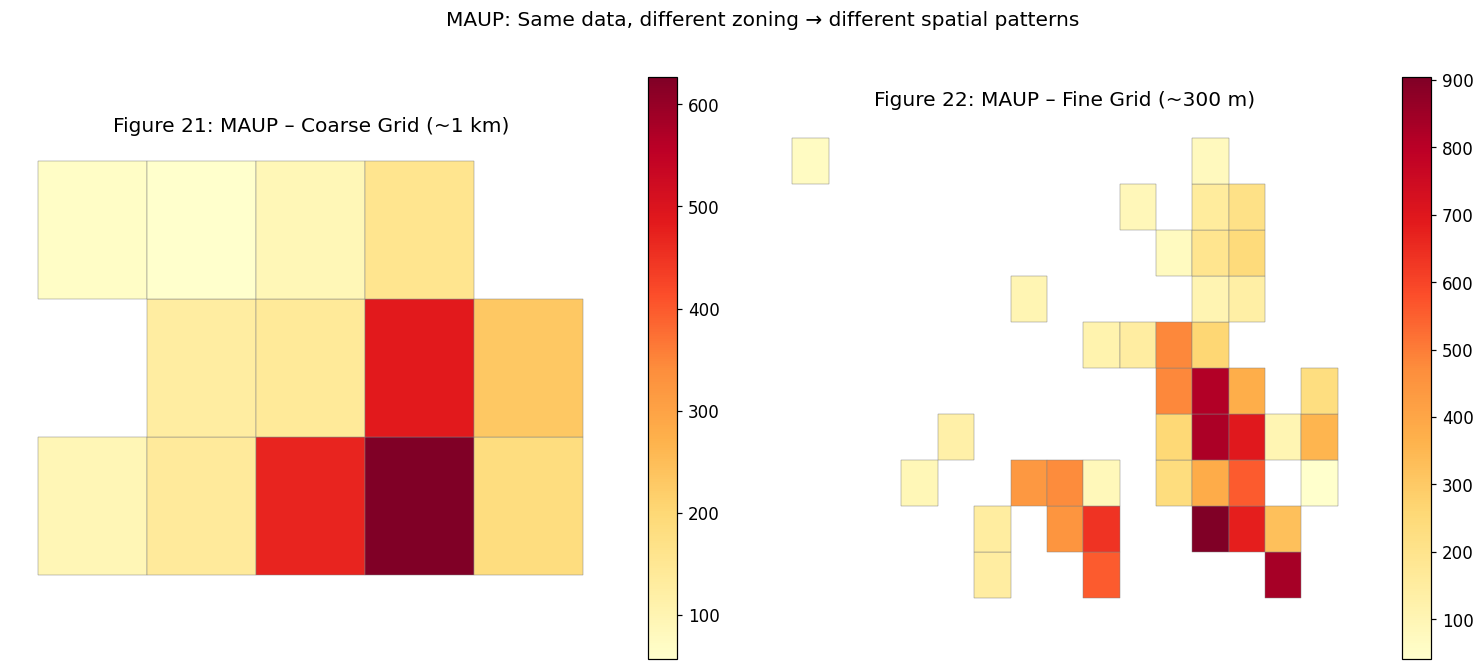

In [41]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

def grid_aggregate_fast(gdf_pts, size_deg):
    # 1. Get the spatial boundaries of all points
    minx, miny, maxx, maxy = gdf_pts.total_bounds
    
    # 2. Vectorized Math: Instantly assign every point to a grid row/column index
    col_idx = ((gdf_pts.geometry.x - minx) // size_deg).astype(int)
    row_idx = ((gdf_pts.geometry.y - miny) // size_deg).astype(int)
    
    # 3. Create a temporary standard Pandas dataframe for lightning-fast grouping
    df_temp = pd.DataFrame({
        'col': col_idx,
        'row': row_idx,
        'mean_count': gdf_pts['mean_count'].values
    })
    
    # Group by the grid cell indices and calculate the mean
    grouped = df_temp.groupby(['row', 'col'])['mean_count'].mean().reset_index()
    
    # 4. Reconstruct the square polygons ONLY for the grid cells that actually contain sensors
    polys = []
    for _, row_data in grouped.iterrows():
        r = row_data['row']
        c = row_data['col']
        
        # Find the bottom-left corner of this specific cell
        cell_minx = minx + (c * size_deg)
        cell_miny = miny + (r * size_deg)
        
        # Draw the box for the final map
        polys.append(box(cell_minx, cell_miny, cell_minx + size_deg, cell_miny + size_deg))
        
    # Return the final GeoDataFrame
    return gpd.GeoDataFrame({'mean_count': grouped['mean_count']}, geometry=polys, crs=gdf_pts.crs)

# Prepare the data
gdf_pts = gdf.copy()
if 'mean_count' not in gdf_pts.columns:
    gdf_pts['mean_count'] = sensor_feats['mean_count'].values

# Ensure we are in EPSG:4326 to use decimal degrees like your original code
if gdf_pts.crs.to_string() != 'EPSG:4326':
    gdf_pts = gdf_pts.to_crs('EPSG:4326')

# Run the lightning-fast version
coarse = grid_aggregate_fast(gdf_pts, 0.010)   # ~1 km
fine   = grid_aggregate_fast(gdf_pts, 0.003)   # ~300 m

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

coarse.plot(column='mean_count', cmap='YlOrRd', legend=True,
            ax=axes[0], edgecolor='grey', lw=0.3)
axes[0].set_title('Figure 21: MAUP – Coarse Grid (~1 km)') 
axes[0].axis('off')

fine.plot(column='mean_count', cmap='YlOrRd', legend=True,
          ax=axes[1], edgecolor='grey', lw=0.3)
axes[1].set_title('Figure 22: MAUP – Fine Grid (~300 m)') 
axes[1].axis('off')

plt.suptitle('MAUP: Same data, different zoning → different spatial patterns', y=1.01)
plt.tight_layout()
plt.show()

## 7. Temporal Data Mining

In [42]:
# ── 7.1 Motif Discovery ─────────────────────────────────────────────────────
# Motif patterns in time series are a key STDM pattern mining task.
# Conceptual discussion is included in Section 10 (Summary).
# The anomaly detection methods in Section 7.2 (Z-score, Isolation Forest)
# complement motif discovery by identifying unusual temporal patterns.
print('Motif discussion: see Section 10 and anomaly detection in Section 7.2')

Motif discussion: see Section 10 and anomaly detection in Section 7.2


Z-score anomalies (|z|>3): 22


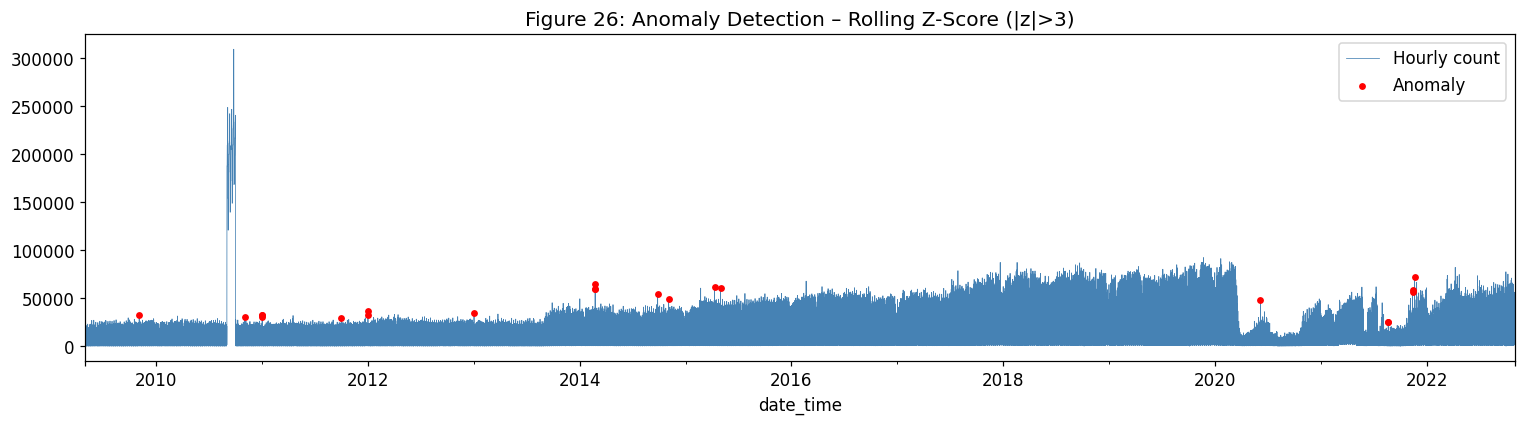

Isolation Forest anomalies (2% contamination): 2364
Dates flagged by BOTH methods: 1


In [43]:
# ── 7.2 Anomaly Detection ─────────────────────────────────────────────────────
# Method A: Rolling Z-score
roll_mean = ts_city.rolling(24*7, center=True, min_periods=1).mean()
roll_std  = ts_city.rolling(24*7, center=True, min_periods=1).std().fillna(1)
z_score   = (ts_city - roll_mean) / roll_std
anom_z    = ts_city[z_score.abs() > 3]
print(f'Z-score anomalies (|z|>3): {len(anom_z)}')

plt.figure(figsize=(14, 4))
ts_city.plot(lw=0.5, color='steelblue', label='Hourly count')
plt.scatter(anom_z.index, anom_z.values, color='red', s=12, zorder=5, label='Anomaly')
plt.title('Figure 26: Anomaly Detection – Rolling Z-Score (|z|>3)')
plt.legend(); plt.tight_layout(); plt.show()

# Method B: Isolation Forest
anf_feats = feat_ts_city[['count','hour','dow','month','lag_24h','roll_mean_24h']].dropna().copy()
anf_feats['iso_flag'] = IsolationForest(contamination=0.02, random_state=SEED).fit_predict(anf_feats)
iso_anom = anf_feats[anf_feats['iso_flag'] == -1]
print(f'Isolation Forest anomalies (2% contamination): {len(iso_anom)}')

both = set(anom_z.index.date) & set(iso_anom.index.date)
print(f'Dates flagged by BOTH methods: {len(both)}')

In [44]:
# ── 7.3 SAX-inspired Sequence / N-gram Pattern Mining ────────────────────────
# Step 1: PAA (Piecewise Aggregate Approximation)
# Aggregate the hourly city series into daily totals (each day = one PAA segment)
ts_daily_city = ts_city.resample('D').sum()

# Step 2: SAX-style symbolic discretization using equal-frequency breakpoints
# Divide the value range into 3 equiprobable symbols: L (low), M (medium), H (high)
# This mirrors the SAX alphabet-size=3 approach from the lectures
q1 = ts_daily_city.quantile(1/3)
q2 = ts_daily_city.quantile(2/3)
sax_seq = ts_daily_city.map(lambda v: 'L' if v < q1 else ('M' if v < q2 else 'H')).values

print('PAA segment size : 1 day (24 hourly values averaged per segment)')
print(f'SAX alphabet     : {{L (< {q1:.0f}), M ({q1:.0f}–{q2:.0f}), H (> {q2:.0f})}}')
print(f'SAX word length  : {len(sax_seq)} symbols (one per day)')
print('\nSample (first 30 days):', ' '.join(sax_seq[:30]))

# Step 3: N-gram pattern mining on the SAX string
bigrams  = Counter(zip(sax_seq, sax_seq[1:]))
trigrams = Counter(zip(sax_seq, sax_seq[1:], sax_seq[2:]))

print('\nTop-10 SAX Bigrams:')
for k, v in bigrams.most_common(10):
    print(f'  {"→".join(k):8s}: {v:4d}  ({v/len(sax_seq)*100:.1f}%)')

print('\nTop-10 SAX Trigrams:')
for k, v in trigrams.most_common(10):
    print(f'  {"→".join(k):12s}: {v:4d}')


PAA segment size : 1 day (24 hourly values averaged per segment)
SAX alphabet     : {L (< 247395), M (247395–476507), H (> 476507)}
SAX word length  : 4932 symbols (one per day)

Sample (first 30 days): L L L L L L L L L L L L L L L L L L L L L M L L L L L L M L

Top-10 SAX Bigrams:
  L→L     : 1423  (28.9%)
  H→H     : 1399  (28.4%)
  M→M     : 1180  (23.9%)
  H→M     :  244  (4.9%)
  M→H     :  244  (4.9%)
  L→M     :  220  (4.5%)
  M→L     :  220  (4.5%)
  L→H     :    1  (0.0%)

Top-10 SAX Trigrams:
  L→L→L       : 1237
  H→H→H       : 1220
  M→M→M       :  970
  L→L→M       :  185
  M→L→L       :  185
  H→H→M       :  178
  M→H→H       :  178
  L→M→L       :  155
  M→M→H       :  148
  H→M→M       :  145


## 8. Joint Spatio-Temporal Inference

In [45]:
# ── 8.1 Per-sensor STL-derived temporal statistics ────────────────────────────
sensor_ts_extra = {}
for sid in sensor_feats['sensor_id'].values:
    s = (
        df[df['sensor_id'] == sid]
        .set_index('date_time')['hourly_counts']
        .resample('D').sum()
        .fillna(method='ffill')
    )
    if len(s) < 30:
        continue
    try:
        r = STL(s, period=7, robust=True).fit()
        sensor_ts_extra[sid] = {
            'trend_slope': np.polyfit(np.arange(len(r.trend)), r.trend, 1)[0],
            'seas_amp'   : r.seasonal.std(),
            'resid_var'  : r.resid.var(),
        }
    except Exception:
        pass

df_ts_extra = pd.DataFrame.from_dict(sensor_ts_extra, orient='index').reset_index()
df_ts_extra.columns = ['sensor_id', 'trend_slope', 'seas_amp', 'resid_var']

joint_df = sensor_feats.merge(df_ts_extra, on='sensor_id', how='inner')
print('Joint ST feature table:', joint_df.shape)
joint_df[['sensor_id','lat','lon','mean_count','trend_slope','seas_amp','resid_var']].head()

Joint ST feature table: (73, 53)


,sensor_id,lat,lon,mean_count,trend_slope,seas_amp,resid_var
0,1,-37.813494,144.965153,1043.850789,1.027698,3062.982382,1.138384e+07
1,2,-37.813807,144.965167,945.819468,-3.890532,3069.137655,8.627359e+06
2,3,-37.811015,144.964295,1087.239110,-2.635353,2873.309166,7.638159e+06
3,4,-37.814880,144.966088,1348.215740,-4.656775,3533.148221,9.502456e+06
4,5,-37.818742,144.967877,997.015730,-0.531869,3016.729593,1.402865e+07


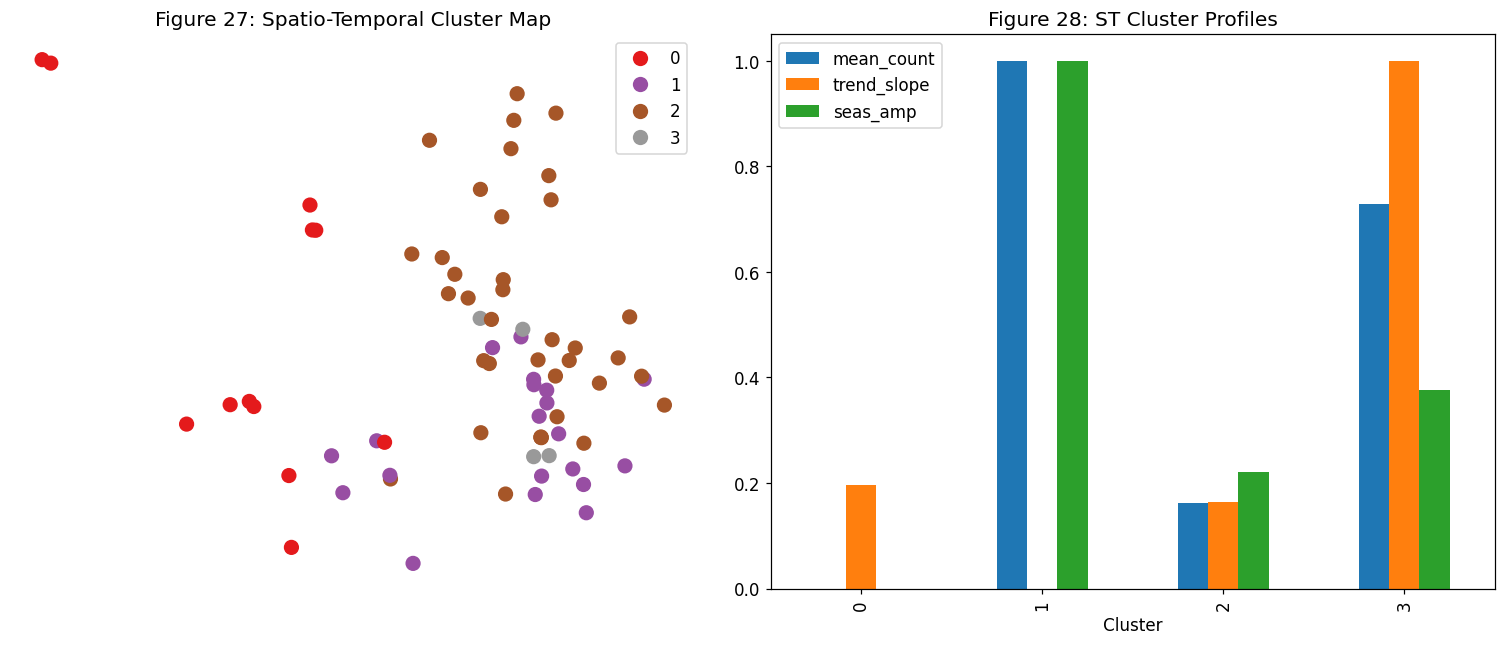

In [46]:
# ── 8.2 Spatio-Temporal K-Means Clustering ────────────────────────────────────
ST_COLS = ['lat','lon','mean_count','trend_slope','seas_amp','resid_var']
ST_COLS = [c for c in ST_COLS if c in joint_df.columns]
X_st_s  = StandardScaler().fit_transform(joint_df[ST_COLS].dropna().values)

joint_df['st_cluster'] = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit_predict(X_st_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gdf_st = gdf.loc[gdf['sensor_id'].isin(joint_df['sensor_id'])].copy()
gdf_st['st_cluster'] = joint_df['st_cluster'].values.astype(str)
gdf_st.plot(column='st_cluster', cmap='Set1', markersize=80, legend=True, ax=axes[0])
axes[0].set_title('Figure 27: Spatio-Temporal Cluster Map'); axes[0].axis('off')

joint_df.groupby('st_cluster')[['mean_count','trend_slope','seas_amp']].mean().apply(
    lambda x: (x - x.min())/(x.max()-x.min())).plot(kind='bar', ax=axes[1])
axes[1].set_title('Figure 28: ST Cluster Profiles')
axes[1].set_xlabel('Cluster')
plt.tight_layout()
plt.show()

In [47]:
# ── 8.3 Joint ST Prediction – RF & XGBoost ───────────────────────────────────
# Merge spatial features onto every hourly row, then add Fourier time features
SP_JOIN = ['sensor_id','lat','lon','dist_centre_km',
           'nn_mean_count','cv','g_star_z','lisa_I','we_wd_ratio']
SP_JOIN = [c for c in SP_JOIN if c in sensor_feats.columns]

df_ml = df.merge(sensor_feats[SP_JOIN], on='sensor_id', how='left')

# FIX: Force the 'month' column to be numeric (1-12) instead of strings
df_ml['month'] = df_ml['date_time'].dt.month

# Use 'time' column (0-23) for hour – already in dataset
for k in [1, 2]:
    df_ml[f'sin_h{k}'] = np.sin(2*np.pi*k*df_ml['time']/24)
    df_ml[f'cos_h{k}'] = np.cos(2*np.pi*k*df_ml['time']/24)
    df_ml[f'sin_d{k}'] = np.sin(2*np.pi*k*df_ml['date_time'].dt.dayofyear/365.25)
    df_ml[f'cos_d{k}'] = np.cos(2*np.pi*k*df_ml['date_time'].dt.dayofyear/365.25)

# Sub-sample: 4 time-points per day for tractability
df_sub = df_ml[df_ml['time'].isin([0, 6, 12, 18])].dropna().copy()

JT_FEATS = (
    ['lat','lon','dist_centre_km','nn_mean_count','cv','g_star_z','lisa_I','we_wd_ratio',
     'time','is_weekend','month','year'] +
    [c for c in df_sub.columns if c.startswith('sin_') or c.startswith('cos_')]
)
JT_FEATS = [c for c in JT_FEATS if c in df_sub.columns]

# Temporal train/test split: train ≤2019, test ≥2020
train_mask = df_sub['year'] <= 2019

# FIX: Cleaned up the scaling logic so it only fits once
scaler_j  = StandardScaler()
X_j_tr_s  = scaler_j.fit_transform(df_sub.loc[train_mask, JT_FEATS].values)
X_j_te_s  = scaler_j.transform(df_sub.loc[~train_mask, JT_FEATS].values)

y_j_tr    = df_sub.loc[train_mask,  'hourly_counts'].values
y_j_te    = df_sub.loc[~train_mask, 'hourly_counts'].values

print(f'Joint  train: {X_j_tr_s.shape}   test: {X_j_te_s.shape}')
print('\n=== Joint ST ML (train≤2019, test≥2020) ===')

rf_j = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED)
rf_j.fit(X_j_tr_s, y_j_tr)
ts_metrics('Random Forest (Joint ST)', y_j_te, np.clip(rf_j.predict(X_j_te_s), 0, None))

if BOOST_OK:
    xgb_j = XGBRegressor(n_estimators=300, random_state=SEED, verbosity=0, n_jobs=-1)
    xgb_j.fit(X_j_tr_s, y_j_tr)
    ts_metrics('XGBoost (Joint ST)', y_j_te, np.clip(xgb_j.predict(X_j_te_s), 0, None))

Joint  train: (438277, 20)   test: (258322, 20)

=== Joint ST ML (train≤2019, test≥2020) ===
Random Forest (Joint ST)                          MAE=   347.1  RMSE=   633.5  MAPE=277613369287.43%
XGBoost (Joint ST)                                MAE=   375.2  RMSE=   662.2  MAPE=341310343992.33%


In [48]:
# ── 8.4 STDM: Spatio-Temporal Similarity Scoring ─────────────────────────────
# Rank sensor pairs by combined geographic proximity + temporal correlation
common       = joint_df['sensor_id'].values
common_names = [sensor_map[c] if c in sensor_map.index else str(c) for c in common]
ts_wide_cols = ts_wide.columns.tolist()
valid_names  = [c for c in common_names if c in ts_wide_cols]
valid_idx    = [i for i, c in enumerate(common_names) if c in ts_wide_cols]

ts_w   = ts_wide[valid_names].fillna(0)
temp_c = ts_w.corr().values

# Use only sensors that appear in ts_wide for geo distance
joint_valid = joint_df.iloc[valid_idx].copy()
s_coords_r  = np.radians(joint_valid[['lat','lon']].values)
geo_d   = haversine_distances(s_coords_r) * R_EARTH
geo_sim = 1 / (geo_d + 0.01)

mms    = MinMaxScaler()
st_sim = 0.5 * mms.fit_transform(temp_c) + 0.5 * mms.fit_transform(geo_sim)

triu  = np.triu_indices(len(valid_names), k=1)
top10 = sorted(zip(st_sim[triu], triu[0], triu[1]), reverse=True)[:10]
print('Top-10 Spatio-Temporally Similar Sensor Pairs:')
for score, i, j in top10:
    print(f'  {valid_names[i]} ↔ {valid_names[j]}   ST_sim={score:.4f}')

gc.collect()


Top-10 Spatio-Temporally Similar Sensor Pairs:
  Flinders Ln -Degraves St (North) ↔ Flinders Ln -Degraves St (Crossing)   ST_sim=0.8843
  Flinders Ln -Degraves St (South) ↔ Flinders Ln -Degraves St (Crossing)   ST_sim=0.8650
  Flinders Ln -Degraves St (South) ↔ Flinders Ln -Degraves St (North)   ST_sim=0.8310
  Spencer St-Collins St (South) ↔ Spencer St-Collins St (North)   ST_sim=0.6246
  Harbour Esplanade (West) - Pedestrian Pa ↔ Harbour Esplanade (West) - Bike Path   ST_sim=0.5726
  Collins Place (South) ↔ Collins Place (North)   ST_sim=0.5625
  Chinatown-Lt Bourke St (South) ↔ Bourke St-Russell St (West)   ST_sim=0.5287
  QVM-Therry St (South) ↔ QVM-Franklin St (North)   ST_sim=0.5195
  Monash Rd-Swanston St (West) ↔ Tin Alley-Swanston St (West)   ST_sim=0.5143
  Flinders St (South) ↔ Elizabeth St - Flinders St (East) - New footpath   ST_sim=0.5091


15380

## 9. Visualizations of Feature Spaces

Explained variance: [0.402 0.157 0.129]


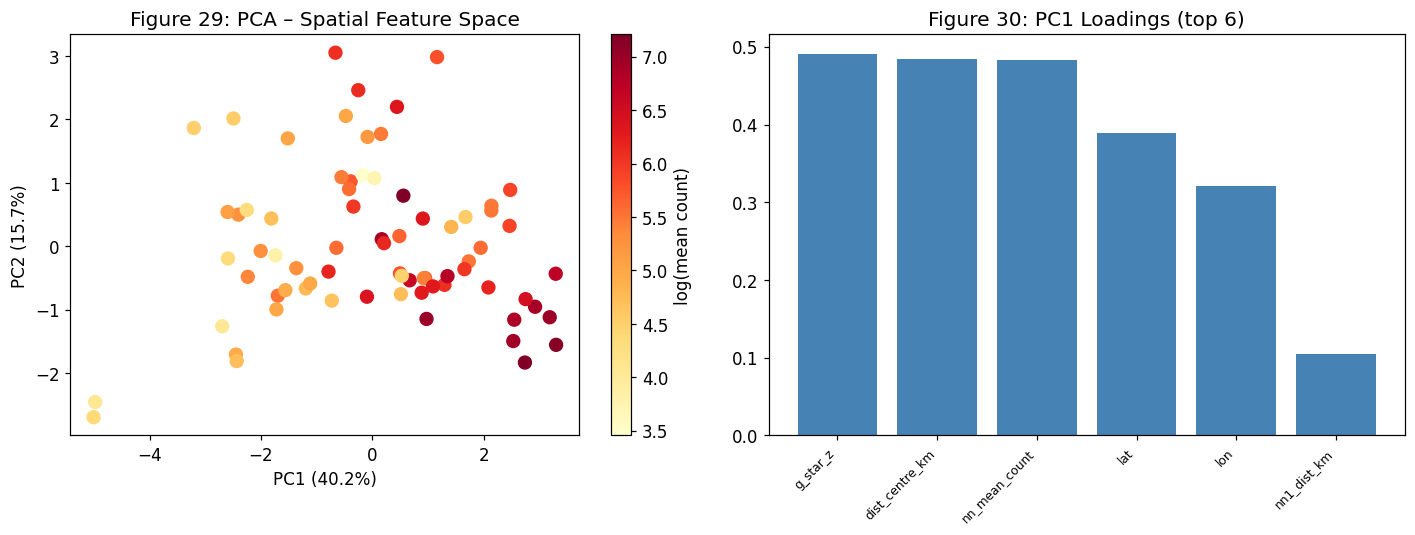

In [50]:
# ── 9.1 PCA of Spatial Feature Space ─────────────────────────────────────────
pca    = PCA(n_components=3)
X_pca  = pca.fit_transform(StandardScaler().fit_transform(X_sp))
print('Explained variance:', np.round(pca.explained_variance_ratio_, 3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(X_pca[:,0], X_pca[:,1],
                     c=np.log1p(sensor_feats['mean_count'].values),
                     cmap='YlOrRd', s=70)
plt.colorbar(sc, ax=axes[0], label='log(mean count)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Figure 29: PCA – Spatial Feature Space')

top_load = np.argsort(np.abs(pca.components_[0]))[::-1][:6]
axes[1].bar(range(6), np.abs(pca.components_[0][top_load]), color='steelblue')
axes[1].set_xticks(range(6))
axes[1].set_xticklabels([SPATIAL_FEATS[i] for i in top_load],
                         rotation=45, ha='right', fontsize=8)
axes[1].set_title('Figure 30: PC1 Loadings (top 6)')
plt.tight_layout()
plt.show()

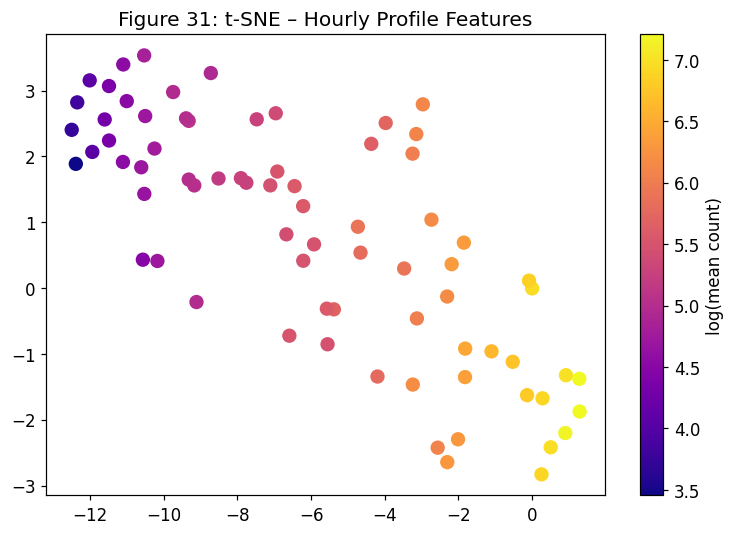

In [51]:
# ── 9.2 t-SNE – Hourly Profile Feature Space ─────────────────────────────────
H_COLS2 = [c for c in sensor_feats.columns if c.startswith('h')]
X_hp    = StandardScaler().fit_transform(sensor_feats[H_COLS2].values)
perp    = min(30, max(5, len(X_hp) // 3))
X_tsne  = TSNE(n_components=2, perplexity=perp, random_state=SEED).fit_transform(X_hp)

color_vals = np.log1p(sensor_feats['mean_count'].values)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
sc1 = ax.scatter(X_tsne[:,0], X_tsne[:,1], c=color_vals, cmap='plasma', s=70)
plt.colorbar(sc1, ax=ax, label='log(mean count)')
ax.set_title('Figure 31: t-SNE – Hourly Profile Features')
plt.tight_layout()
plt.show()


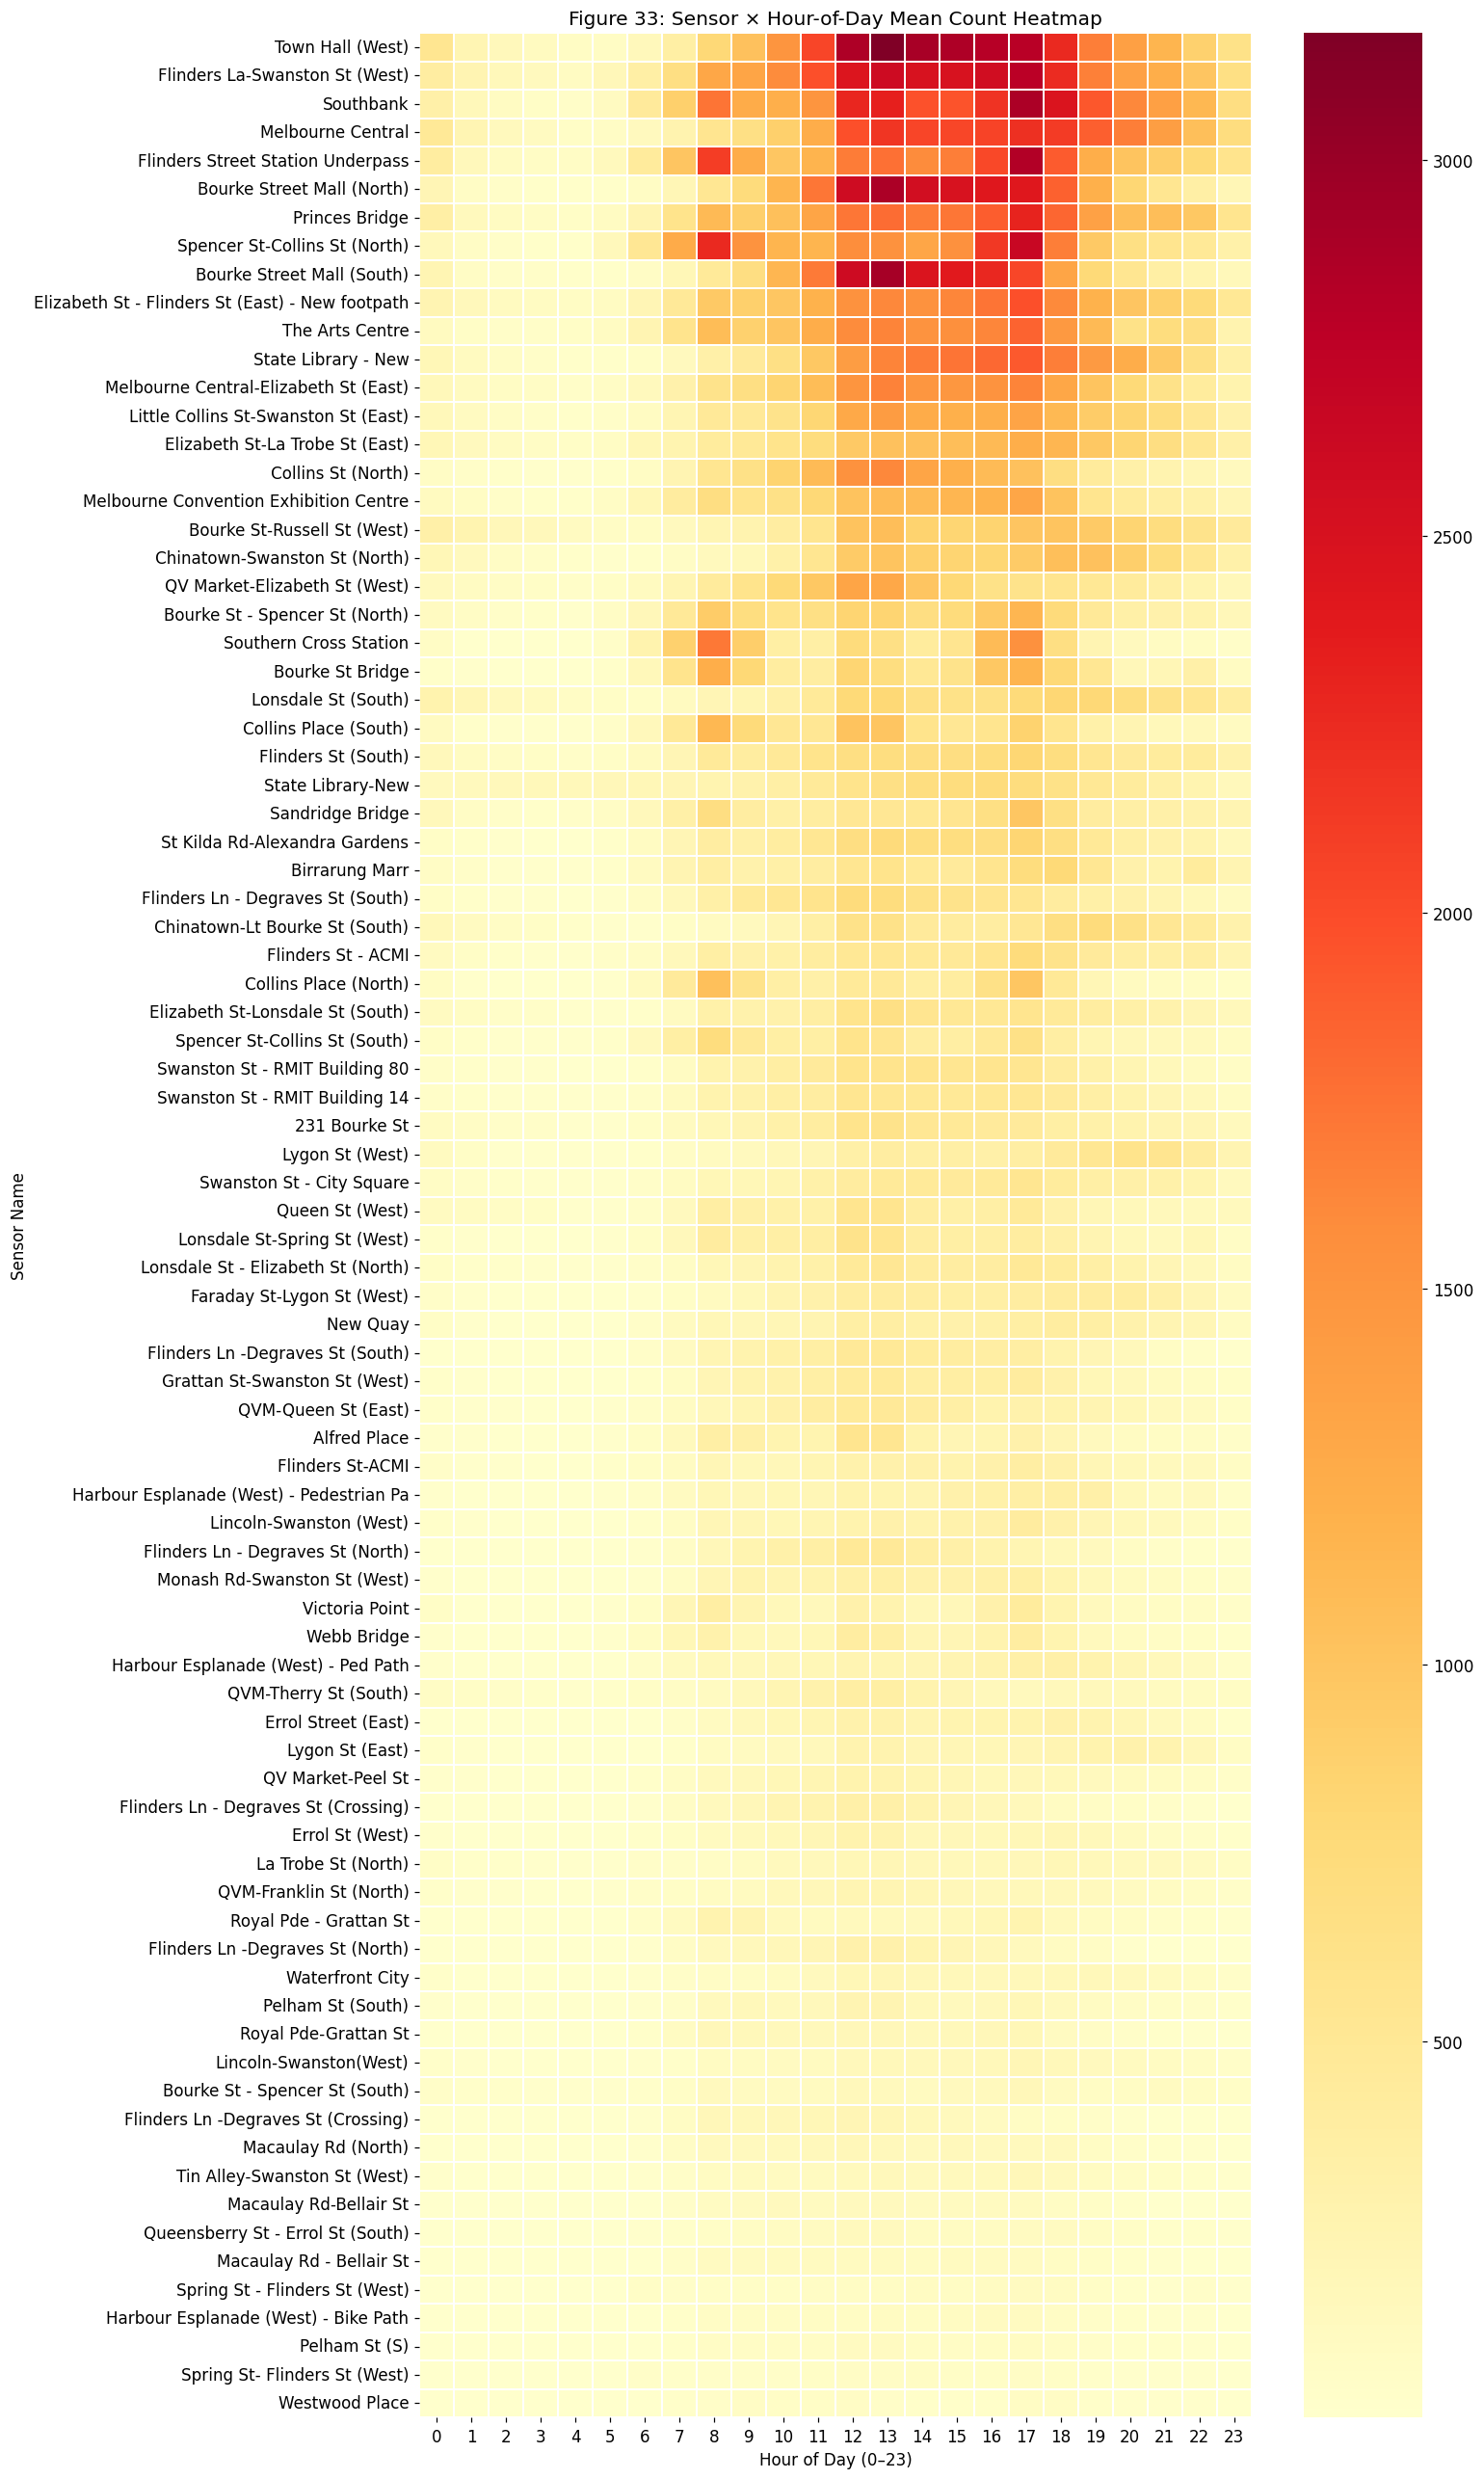

In [52]:
# ── 9.3 Sensor × Hour-of-Day Heatmap ─────────────────────────────────────────
# Uses 'sensor_name' (readable) and 'time' (0-23)
heat = (
    df.groupby(['sensor_name', 'time'])['hourly_counts']
    .mean()
    .unstack(fill_value=0)
)
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(14, max(6, len(heat) * 0.28)))
sns.heatmap(heat, cmap='YlOrRd', linewidths=0.05, linecolor='white',
            xticklabels=True, yticklabels=True)
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Sensor Name')
plt.title('Figure 33: Sensor × Hour-of-Day Mean Count Heatmap')
plt.tight_layout()
plt.show()

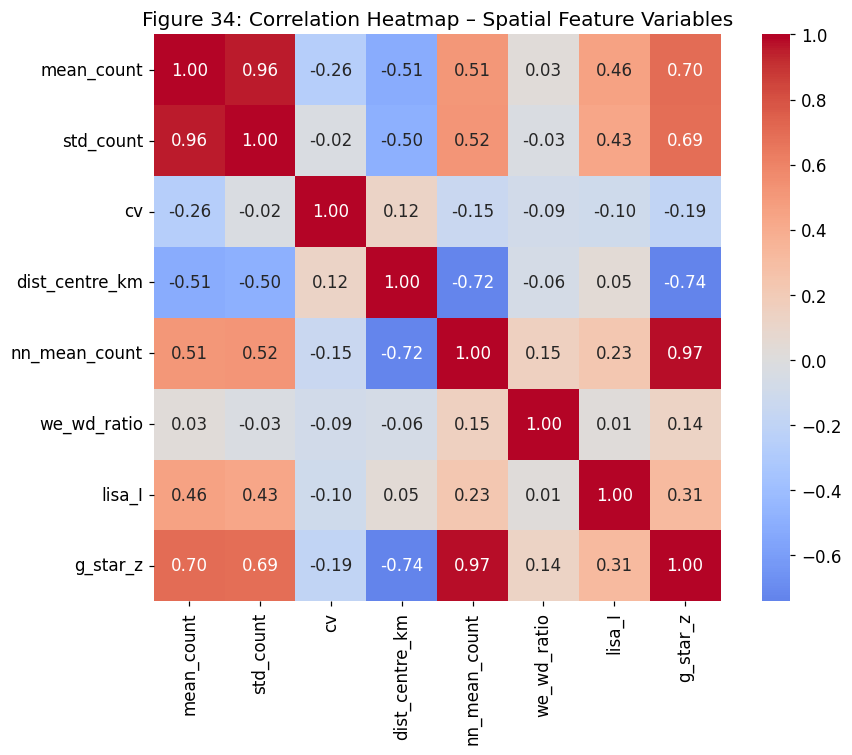

In [53]:
# ── 9.4 Spatial Feature Correlation Heatmap ───────────────────────────────────
corr_cols = ['mean_count','std_count','cv','dist_centre_km',
             'nn_mean_count','we_wd_ratio','lisa_I','g_star_z']
corr_cols = [c for c in corr_cols if c in sensor_feats.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(sensor_feats[corr_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Figure 34: Correlation Heatmap – Spatial Feature Variables')
plt.tight_layout()
plt.show()

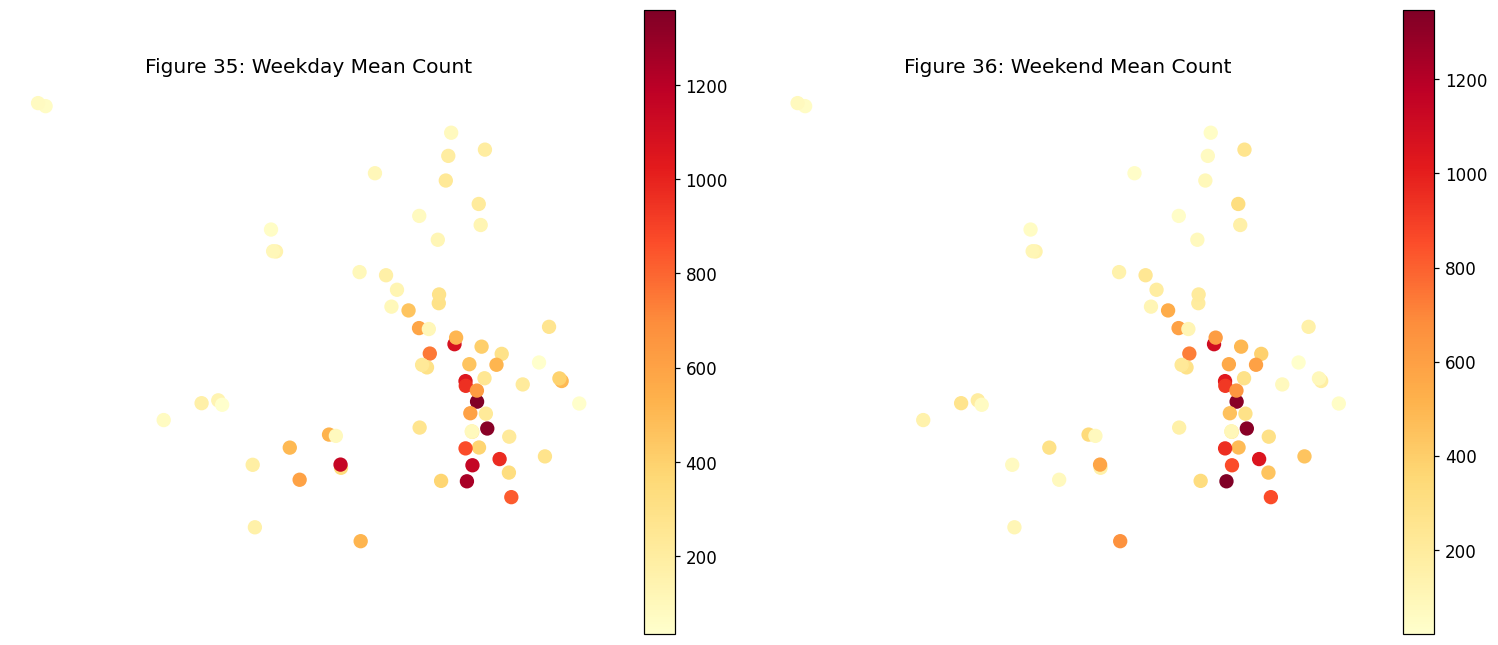

In [54]:
# ── 9.5 Weekday vs Weekend Spatial Maps ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in [
    (axes[0], 'weekday_mean', 'Figure 35: Weekday Mean Count'),
    (axes[1], 'weekend_mean', 'Figure 36: Weekend Mean Count'),
]:
    gdf_tmp = gdf.copy()
    gdf_tmp[col] = sensor_feats[col].values
    gdf_tmp.plot(column=col, cmap='YlOrRd', legend=True, markersize=70, ax=ax)
    ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.show()